# Analizamos el exp de 06/2025
* Corremos en entorno PKLS

In [2]:
# Antes de correr este archivo, renombrar los videos usando "Rename czi files.ipynb"

# Importo librerías necesarias
from ipynb.fs.defs.aux_functions import *

from ipywidgets import interact, interact_manual, interactive, fixed
from IPython.display import display
import pandas as pd

from os.path import exists
from PIL import Image

c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.

## Levantamos pkls

In [3]:
areas_dir = r'C:\Users\PC\Documents\GitHub\social_isolation_habenula_imaging\Exp_25\PKL 06-2025'
# areas_dir = r'C:\Users\PC\Desktop\Analisis conf\PKL 11-2024'
areas = load_areas(areas_dir)

for key in areas:
    print(key + ":", len(areas[key].trials), "trials.")

113-1: 10 trials.
114-1: 10 trials.
115-1: 10 trials.
116-1: 10 trials.
117-1: 10 trials.
118-1: 10 trials.
120-1: 10 trials.
121-1: 10 trials.
122-1: 10 trials.
123-1: 10 trials.
124-1: 10 trials.
125-1: 10 trials.
126-1: 10 trials.
127-1: 10 trials.
129-1: 10 trials.
130-1: 10 trials.
131-1: 10 trials.
132-1: 10 trials.
133-1: 10 trials.
134-1: 10 trials.
135-1: 10 trials.
136-1: 10 trials.
137-1: 10 trials.
138-1: 10 trials.
139-1: 10 trials.
143-1: 10 trials.


In [4]:
disk_dir = r"C:\Users\PC\My Drive\Violeta"

os.chdir(disk_dir)  
dataset_2 = pd.read_excel("HabenulaPosta.xlsx")


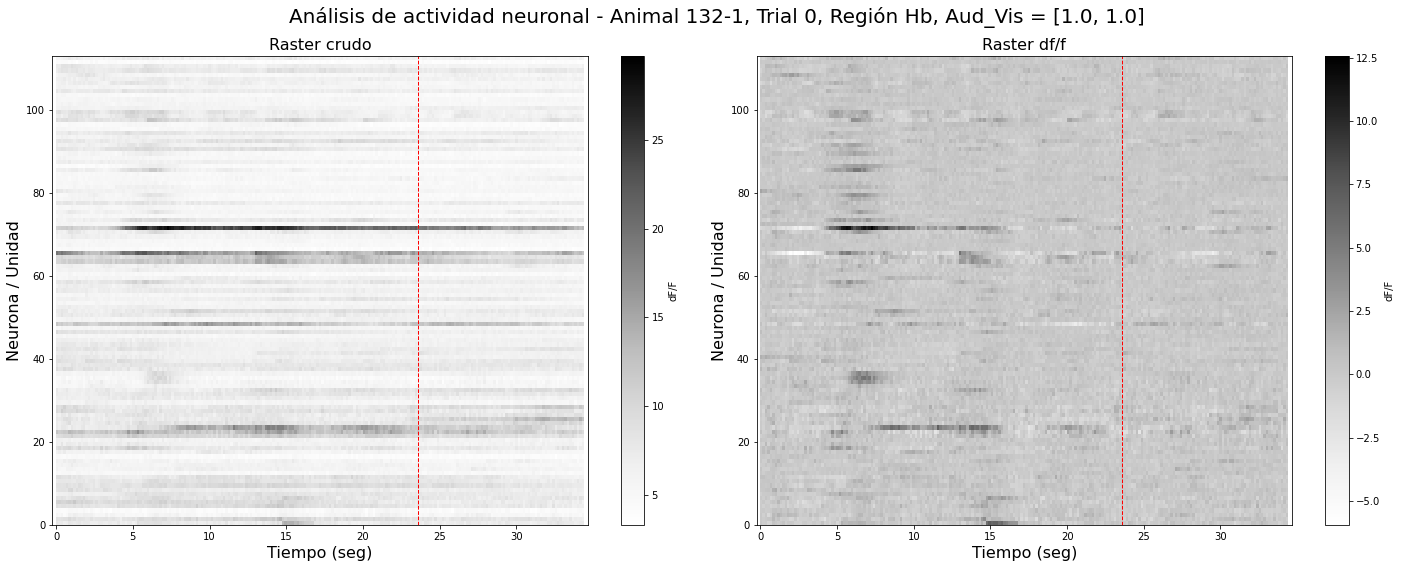

In [86]:
key= '132-1'
region = 'Hb'
trial = 0
if type(trial) == int:
    trials_to_plot = [trial]
else:
    trials_to_plot = range(len(areas[key].trials))
for trial in trials_to_plot:
    t_tot = round(areas[key].trials[trial].total_time,2)
    aud_vis = [areas[key].trials[trial].aud, float(areas[key].trials[trial].vis)]
    roi_activity = areas[key].trials[trial].roi_activities[region]

    dffs = areas[key].trials[trial].roi_dffs[region]



    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'Análisis de actividad neuronal - Animal {key}, Trial {trial}, Región {region}, Aud_Vis = {aud_vis}', fontsize=20)

    # Raster plot data cruda
    ax1 = axes[0]
    im = ax1.imshow(roi_activity, aspect='auto', cmap='Greys', interpolation='nearest',
                    extent=[0, t_tot, 0, roi_activity.shape[0]])
    fig.colorbar(im, ax=ax1, label='dF/F')
    ax1.set_xlabel('Tiempo (seg)', fontsize=16)
    ax1.set_ylabel('Neurona / Unidad', fontsize=16)
    ax1.set_title('Raster crudo', fontsize=16)
    ax1.set_xlim(-.25, t_tot+.25)
    ax1.axvline(x=23.6, color='red', linestyle='--', linewidth=1)  # línea punteada roja

    # Raster plot df/f
    ax2 = axes[1]
    im = ax2.imshow(dffs, aspect='auto', cmap='Greys', interpolation='nearest',
                    extent=[0, t_tot, 0, dffs.shape[0]])
    fig.colorbar(im, ax=ax2, label='dF/F')
    ax2.set_xlabel('Tiempo (seg)', fontsize=16)
    ax2.set_ylabel('Neurona / Unidad', fontsize=16)
    ax2.set_title('Raster df/f', fontsize=16)
    ax2.set_xlim(-.25, t_tot+.25)
    ax2.axvline(x=23.6, color='red', linestyle='--', linewidth=1)  # línea punteada roja

    plt.tight_layout()
    plt.show()



In [5]:
for key in areas:
    areas[key].edad = areas[key].trials[0].data['Edad']
    areas[key].n_un_hb = len(areas[key].trials[0].roi_activities['Hb'])
    areas[key].aislado = list(dataset_2['aislado'][dataset_2['animal']==int(key[:-2])])[0]


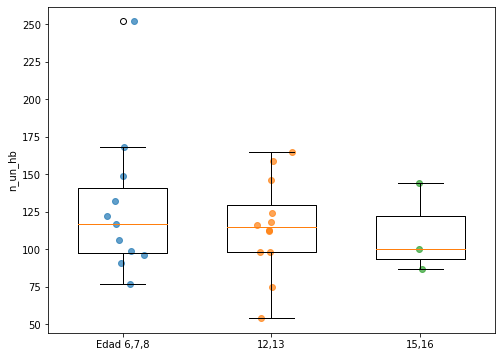

In [ ]:

positions = [1, 2, 3]

n_un_hb_8 = [a.n_un_hb for a in areas.values() if 0 < a.edad <= 8]
n_un_hb_13 = [a.n_un_hb for a in areas.values() if 8 < a.edad <= 13]
n_un_hb_16 = [a.n_un_hb for a in areas.values() if 13 < a.edad <= 16]

data = [n_un_hb_8, n_un_hb_13, n_un_hb_16]
fig = plt.figure(figsize=(8, 6))
# --- Boxplot ---
plt.boxplot(data, positions=positions, widths=0.6)

# --- Scatter con jitter ---
for pos, vals in zip(positions, data):
    jitter = np.random.normal(0, 0.05, size=len(vals))  # ruido en X
    plt.scatter(np.full(len(vals), pos) + jitter, vals, alpha=0.7)

plt.xticks(positions, ['Edad 6,7,8', '12,13', '15,16'])
plt.ylabel("n_un_hb")
fig.patch.set_facecolor('white')
# plt.savefig(f'Edad_vs_Rois.png', dpi=300, bbox_inches='tight')
plt.show()

In [117]:
areas[key].trials[0].roi_activities['Hb'].shape

(144, 215)

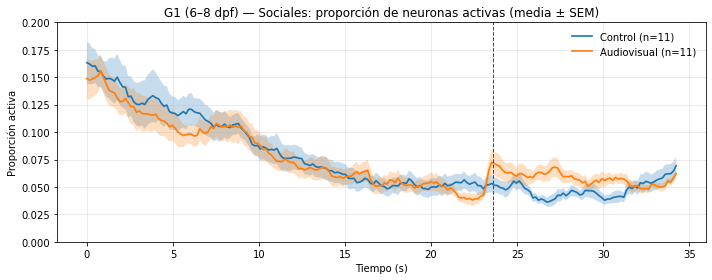

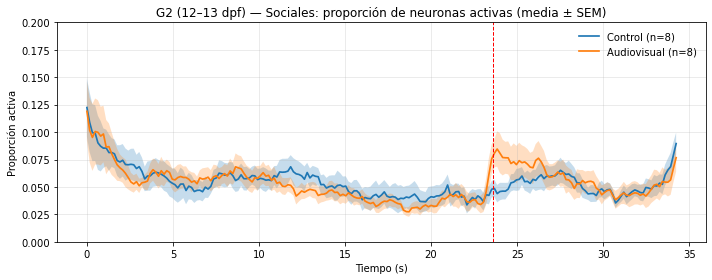

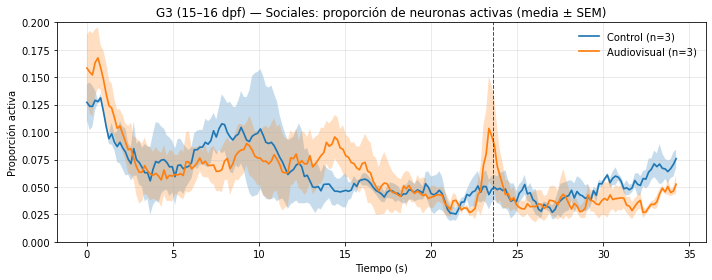

In [5]:
# import numpy as np
# import matplotlib.pyplot as plt

# --- Parámetros específicos de tu dataset ---
ROI_KEY = 'Hb'
FPS = 6.25
GRUPOS = {
    "G1 (6–8 dpf)": {6, 7, 8},
    "G2 (12–13 dpf)": {12, 13},
    "G3 (15–16 dpf)": {15, 16},
}

# Contenedores: por grupo guardamos listas de series (una por animal/área)
grupos_data = {g: {"ctrl": [], "av": []} for g in GRUPOS}

# Recorremos solo animales sociales y armamos promedio por área separado (ctrl / av)
for area in (areas.values() if hasattr(areas, "values") else areas):
    if getattr(area, "aislado", None) != 0:
        continue
    edad = int(getattr(area, "edad", -1))
    # Determinar a qué grupo pertenece este animal
    grupo_nombre = None
    for gname, edades in GRUPOS.items():
        if edad in edades:
            grupo_nombre = gname
            break
    if grupo_nombre is None:
        continue  # edad fuera de los grupos pedidos

    # --- Trials control (vis=0, aud=0) ---
    ctrl_series = []
    for tr in getattr(area, "trials", []):
        if getattr(tr, "vis", None) == 0 and getattr(tr, "aud", None) == 0:
            rb = getattr(tr, "roi_binaries", None)
            if isinstance(rb, dict) and ROI_KEY in rb:
                # roi_binaries['Hb'] es [neuronas x frames], binario 0/1
                mat = np.asarray(rb[ROI_KEY], dtype=float)       # [Nneur x Nframes]
                ctrl_series.append(mat.mean(axis=0))             # proporción activa por frame

    # --- Trials audiovisuales (vis=1, aud=1) ---
    av_series = []
    for tr in getattr(area, "trials", []):
        if getattr(tr, "vis", None) == 1 and getattr(tr, "aud", None) == 1:
            rb = getattr(tr, "roi_binaries", None)
            if isinstance(rb, dict) and ROI_KEY in rb:
                mat = np.asarray(rb[ROI_KEY], dtype=float)       # [Nneur x Nframes]
                av_series.append(mat.mean(axis=0))

    # Promedio por área (si hay al menos un trial válido en cada condición)
    if ctrl_series:
        area_ctrl = np.vstack(ctrl_series).mean(axis=0)          # [Nframes]
        grupos_data[grupo_nombre]["ctrl"].append(area_ctrl)
    if av_series:
        area_av = np.vstack(av_series).mean(axis=0)              # [Nframes]
        grupos_data[grupo_nombre]["av"].append(area_av)

# --- Plot: tres figuras (una por grupo) con media ± SEM para Control y AV ---
for gname, data in grupos_data.items():
    ctrl_list = data["ctrl"]
    av_list   = data["av"]

    if not ctrl_list and not av_list:
        # Nada que plotear para este grupo
        plt.figure(figsize=(10, 4))
        plt.title(f"{gname} — sin datos sociales válidos")
        plt.xlabel("Tiempo (s)")
        plt.ylabel("Proporción de neuronas activas")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        continue

    # Convertimos a matrices [Nanims x Nframes]
    ctrl_M = np.vstack(ctrl_list) if ctrl_list else None
    av_M   = np.vstack(av_list)   if av_list   else None

    # Eje temporal en segundos (tiene igual duración en todos)
    n_frames = ctrl_M.shape[1] if ctrl_M is not None else av_M.shape[1]
    t = np.arange(n_frames) / FPS

    plt.figure(figsize=(10, 4))

    # Curva Control
    if ctrl_M is not None:
        ctrl_mean = ctrl_M.mean(axis=0)
        # SEM: desviación estándar muestral / sqrt(n)
        n_ctrl = ctrl_M.shape[0]
        if n_ctrl > 1:
            ctrl_sem = ctrl_M.std(axis=0, ddof=1) / np.sqrt(n_ctrl)
        else:
            ctrl_sem = np.zeros_like(ctrl_mean)
        plt.plot(t, ctrl_mean, label=f"Control (n={n_ctrl})", linewidth=1.7)
        plt.fill_between(t, ctrl_mean - ctrl_sem, ctrl_mean + ctrl_sem, alpha=0.25)

    # Curva Audiovisual
    if av_M is not None:
        av_mean = av_M.mean(axis=0)
        n_av = av_M.shape[0]
        if n_av > 1:
            av_sem = av_M.std(axis=0, ddof=1) / np.sqrt(n_av)
        else:
            av_sem = np.zeros_like(av_mean)
        plt.plot(t, av_mean, label=f"Audiovisual (n={n_av})", linewidth=1.7)
        plt.fill_between(t, av_mean - av_sem, av_mean + av_sem, alpha=0.25)
    plt.axvline(x=23.6, color='red', linestyle='--', linewidth=1)
    plt.title(f"{gname} — Sociales: proporción de neuronas activas (media ± SEM)")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Proporción activa")
    plt.ylim(0, .20)  # porque es proporción
    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


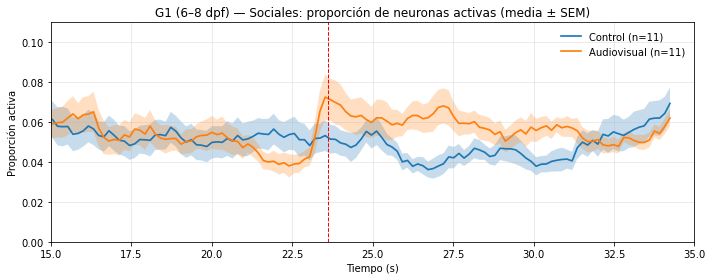

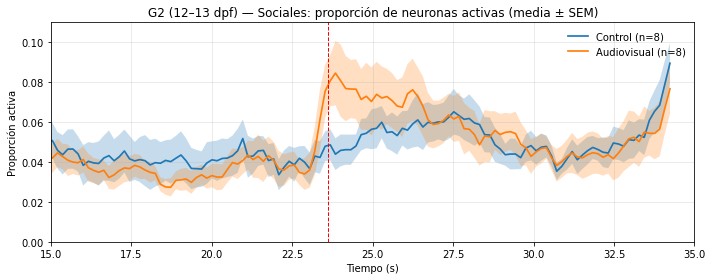

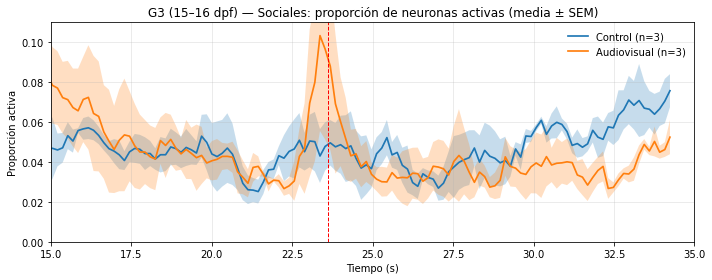

In [8]:
# -*- coding: utf-8 -*-
# ============================================================
# Proporción de neuronas activas por frame (sociales), separado
# en Control (vis=0, aud=0) y Audiovisual (vis=1, aud=1),
# promediado por animal y luego por grupo etario:
#   G1 = 6–8 dpf, G2 = 12–13 dpf, G3 = 15–16 dpf.
# Eje temporal en segundos con FPS=6.25. Se grafica media ± SEM.
#
# Requisitos (según tu dataset):
# - 'areas' es un dict u objeto similar a dict.
# - Cada 'area' tiene: .edad (int), .aislado (0 social / 1 aislado), .trials (lista).
# - Cada 'trial' tiene: .vis, .aud, .roi_binaries (dict con clave 'Hb').
# - trial.roi_binaries['Hb'] es un ndarray (N_neuronas x N_frames), binario 0/1.
# - Todos los trials tienen igual N_frames en todas las áreas.
# - No hay NaNs en roi_binaries['Hb'].
# ============================================================


# -----------------------------
# Parámetros fijos del análisis
# -----------------------------
x_inf_lim = 15
ROI_KEY = 'Hb'                          # Clave de la región de interés dentro de roi_binaries
FPS = 6.25 
SOLO_AISLADOS=False                             # Frecuencia de muestreo (frames por segundo) fija para todas las grabaciones
GRUPOS = {                              # Definición de los grupos etarios pedidos
    "G1 (6–8 dpf)":  {6, 7, 8},
    "G2 (12–13 dpf)": {12, 13},
    "G3 (15–16 dpf)": {15, 16},
}

# -----------------------------------------------------------------------------
# Estructura donde acumularemos, por grupo etario, las series promedio por área
# separadas por condición: 'ctrl' (control) y 'av' (audiovisual).
# Cada entrada será una lista de vectores [N_frames] (uno por área/animal).
# -----------------------------------------------------------------------------
grupos_data = {gname: {"ctrl": [], "av": []} for gname in GRUPOS}  # Inicializamos el contenedor vacío

# ------------------------------------------------------------------------
# Recorremos todas las áreas y filtramos solamente las sociales (aislado=0)
# Para cada área:
#   1) Identificamos a qué grupo etario pertenece (por .edad).
#   2) Calculamos, por trial, la proporción de neuronas activas por frame:
#      mean(neuronas, axis=0) → vector [N_frames] con valores en [0,1].
#   3) Promediamos esos vectores entre los trials de la misma condición
#      (control o audiovisual) → "promedio por área".
#   4) Guardamos el promedio por área en la lista del grupo correspondiente.
# ------------------------------------------------------------------------
for area in (areas.values() if hasattr(areas, "values") else areas):  # Iteramos flexiblemente si 'areas' es dict o lista
    if getattr(area, "aislado", None) == SOLO_AISLADOS:            # Saltamos áreas no-sociales; solo analizamos sociales
                                              # Si aislado != 0, pasamos a la siguiente área

        edad = int(getattr(area, "edad", -1))              # Leemos edad del animal (entero) si no hay valor, pone -1 (centinela)

        # Determinamos el nombre del grupo etario (o None si no encaja)
        grupo_nombre = None                                 # Variable donde guardaremos el grupo al que pertenece el área
        for gname, edades in GRUPOS.items():                # Recorremos cada grupo definido
            if edad in edades:                              # Si la edad del área está dentro del conjunto de ese grupo
                grupo_nombre = gname                        # Asignamos ese nombre de grupo
                break                                       # Cortamos el loop de búsqueda de grupo
        if grupo_nombre is None:                            # Si no pertenece a ninguno de los grupos pedidos
            continue                                        # Pasamos a la siguiente área

        # ---------------------------
        # Trials de condición CONTROL
        # ---------------------------
        ctrl_series = []                                    # Aquí juntaremos los vectores [N_frames] de cada trial control
        for tr in getattr(area, "trials", []):              # Recorremos los 10 trials del área
            # Condición control: vis=0 y aud=0
            if getattr(tr, "vis", None) == 0 and getattr(tr, "aud", None) == 0:
                rb = getattr(tr, "roi_binaries", None)      # Leemos el dict de matrices binarias por ROI
                if isinstance(rb, dict) and ROI_KEY in rb:  # Verificamos que exista la clave 'Hb'
                    mat = np.asarray(rb[ROI_KEY], dtype=float)  # Convertimos a float para operaciones; forma [N_neuronas x N_frames]
                    # Proporción activa por frame = promedio a lo largo de neuronas (columna a columna)
                    # mat.mean(axis=0) devuelve un vector de largo N_frames, con valores entre 0 y 1
                    ctrl_series.append(mat.mean(axis=0))    # Agregamos el vector de este trial a la lista de control

        # ---------------------------------
        # Trials de condición AUDIOVISUAL
        # ---------------------------------
        av_series = []                                      # Aquí juntaremos los vectores [N_frames] de cada trial audiovisual
        for tr in getattr(area, "trials", []):              # Recorremos nuevamente los trials
            # Condición audiovisual: vis=1 y aud=1
            if getattr(tr, "vis", None) == 1 and getattr(tr, "aud", None) == 1:
                rb = getattr(tr, "roi_binaries", None)      # Leemos el dict de matrices binarias por ROI
                if isinstance(rb, dict) and ROI_KEY in rb:  # Verificamos que exista la clave 'Hb'
                    mat = np.asarray(rb[ROI_KEY], dtype=float)  # Convertimos a float; forma [N_neuronas x N_frames]
                    av_series.append(mat.mean(axis=0))      # Proporción activa por frame para este trial AV

        # ------------------------------------------------------------
        # Promedio por ÁREA (animal) para cada condición, si hay datos
        # Tomamos el promedio entre trials dentro de la misma condición.
        # Resultado: un vector [N_frames] por condición y por área.
        # ------------------------------------------------------------
        if ctrl_series:                                     # Si hay al menos 1 trial control válido en esta área
            area_ctrl = np.vstack(ctrl_series).mean(axis=0) # Apilamos a matriz [N_trials_ctrl x N_frames] y promediamos → [N_frames]
            grupos_data[grupo_nombre]["ctrl"].append(area_ctrl)  # Guardamos el promedio por área en el grupo correspondiente

        if av_series:                                       # Si hay al menos 1 trial audiovisual válido en esta área
            area_av = np.vstack(av_series).mean(axis=0)     # Apilamos a matriz [N_trials_av x N_frames] y promediamos → [N_frames]
            grupos_data[grupo_nombre]["av"].append(area_av) # Guardamos el promedio por área en el grupo correspondiente

# --------------------------------------------------------------------
# GRAFICADO: una figura por grupo etario con dos curvas (Control y AV)
# mostrando la media grupal ± SEM (desvío estándar muestral / √n_animales).
# n_animales aquí es el número de áreas sociales válidas que aportaron datos.
# --------------------------------------------------------------------
for gname, data in grupos_data.items():                 # Recorremos los grupos y su información acumulada
    ctrl_list = data["ctrl"]                            # Lista de vectores [N_frames] (uno por área) para CONTROL
    av_list   = data["av"]                              # Lista de vectores [N_frames] (uno por área) para AV

    # Si ambos están vacíos, igualmente generamos una figura informativa
    if not ctrl_list and not av_list:                   # No hay datos para este grupo (por la razón que sea)
        plt.figure(figsize=(10, 4))                     # Creamos figura vacía informativa
        plt.title(f"{gname} — sin datos sociales válidos")  # Título indicando ausencia de datos
        plt.xlabel("Tiempo (s)")                        # Eje X en segundos (mantengo consistencia)
        plt.ylabel("Proporción de neuronas activas")   # Eje Y con etiqueta de proporción
        plt.grid(True, alpha=0.3)                       # Cuadrícula suave para legibilidad
        plt.tight_layout()                              # Ajuste de márgenes
        plt.show()                                      # Mostramos la figura
        continue                                        # Pasamos al siguiente grupo

    # Convertimos listas a matrices 2D para cada condición, si hay datos
    ctrl_M = np.vstack(ctrl_list) if ctrl_list else None  # [N_areas_ctrl x N_frames] o None
    av_M   = np.vstack(av_list)   if av_list   else None  # [N_areas_av   x N_frames] o None

    # Obtenemos N_frames a partir de la primera matriz disponible (todas iguales por requisito)
    n_frames = ctrl_M.shape[1] if ctrl_M is not None else av_M.shape[1]  # Número de frames del registro
    t = np.arange(n_frames) / FPS                       # Vector de tiempo en segundos: [0, 1/FPS, 2/FPS, ...]
    
    plt.figure(figsize=(10, 4))                         # Nueva figura para este grupo

    # -------------------------
    # Curva CONTROL: media ± SEM
    # -------------------------
    if ctrl_M is not None:                              # Si tenemos datos de control en este grupo
        ctrl_mean = ctrl_M.mean(axis=0)                 # Media entre animales (promedio fila a fila) → vector [N_frames]
        n_ctrl = ctrl_M.shape[0]                        # Número de animales (áreas) contribuyendo a control
        # SEM = std_muestral / sqrt(n). Si n=1, SEM = 0 (sin dispersión estimable)
        if n_ctrl > 1:
            ctrl_sem = ctrl_M.std(axis=0, ddof=1) / np.sqrt(n_ctrl)  # Desvío estándar muestral (ddof=1)
        else:
            ctrl_sem = np.zeros_like(ctrl_mean)         # Si hay un solo animal, no podemos estimar SEM → usamos ceros
        plt.plot(t, ctrl_mean, label=f"Control (n={n_ctrl})", linewidth=1.7)  # Trazamos la media de control
        plt.fill_between(t, ctrl_mean - ctrl_sem, ctrl_mean + ctrl_sem, alpha=0.25)  # Sombreado ± SEM

    # -----------------------------
    # Curva AUDIOVISUAL: media ± SEM
    # -----------------------------
    if av_M is not None:                                # Si tenemos datos audiovisuales en este grupo
        av_mean = av_M.mean(axis=0)                     # Media entre animales → vector [N_frames]
        n_av = av_M.shape[0]                            # Número de animales (áreas) contribuyendo a AV
        if n_av > 1:
            av_sem = av_M.std(axis=0, ddof=1) / np.sqrt(n_av)  # SEM para AV
        else:
            av_sem = np.zeros_like(av_mean)             # Si n=1, SEM = 0
        plt.plot(t, av_mean, label=f"Audiovisual (n={n_av})", linewidth=1.7)  # Trazamos la media AV
        plt.fill_between(t, av_mean - av_sem, av_mean + av_sem, alpha=0.25)   # Sombreado ± SEM

    # ----------------------
    # Ajustes finales del plot
    # ----------------------
    plt.axvline(x=23.6, color='red', linestyle='--', linewidth=1)

    plt.title(f"{gname} — Sociales: proporción de neuronas activas (media ± SEM)")  # Título de la figura
    plt.xlabel("Tiempo (s)")                          # Etiqueta del eje X
    plt.ylabel("Proporción activa")                   # Etiqueta del eje Y
    plt.ylim(0, .11)                                    # La proporción está entre 0 y 1
    plt.xlim(x_inf_lim, 35)                                    # La proporción está entre 0 y 1
    plt.grid(True, alpha=0.3)                         # Cuadrícula suave
    plt.legend(frameon=False)                         # Leyenda sin recuadro para estética limpia
    plt.tight_layout()                                # Ajuste de márgenes para evitar solapamientos
    plt.show()                                        # Renderizamos la figura en pantalla


# Evaluamos punto a punto si hay dif significativa 


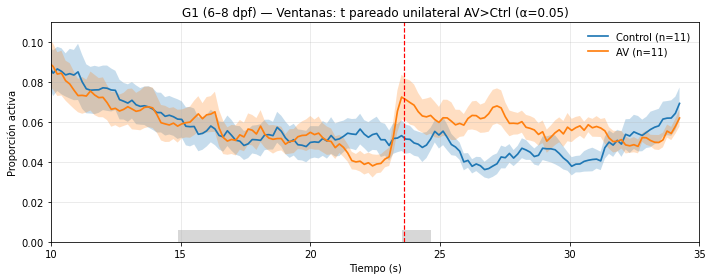

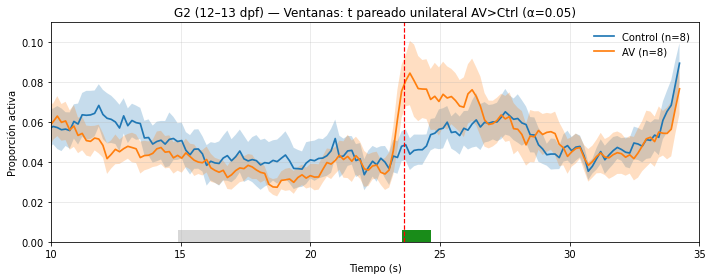

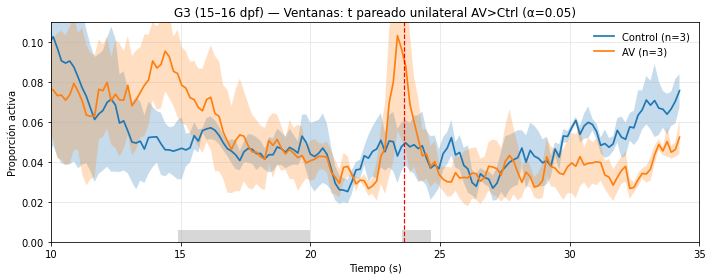

In [165]:
# ====== Parámetros ======
ROI_KEY   = 'Hb'
FPS       = 6.25
Y_MAX     = 0.11          # límite superior del eje Y
T_START_S = 0.0           # graficar desde este segundo
STIM_LINE_S = 23.6        # línea punteada roja

# Ventanas en segundos a testear (lista de (inicio, fin) en s)
# Ejemplos: pre-estímulo, ventana del estímulo, post, etc.
WINDOWS_S = [
    (15, 20),
    (23.6, 24.6),
    # (30.0, 34.0),
]

# Estadística
ALPHA      = 0.05         # nivel de significancia (por ventana)
BAR_HEIGHT = 0.006        # altura de la “barra de significancia” sobre y=0

from scipy import stats
from scipy.stats import t as student_t
import numpy as np
import matplotlib.pyplot as plt

# ====== Curvas por área (promedio por trials dentro de cada condición) ======
GRUPOS = {
    "G1 (6–8 dpf)":  {6, 7, 8},
    "G2 (12–13 dpf)": {12, 13},
    "G3 (15–16 dpf)": {15, 16},
}
grupos_by_area = {g: {"ctrl": {}, "av": {}} for g in GRUPOS}

# Admite dict o lista
iterator = areas.items() if hasattr(areas, "items") else [(str(i), a) for i, a in enumerate(areas)]

for area_key, area in iterator:
    if getattr(area, "aislado", None) != 0:
        continue  # solo sociales
    edad = int(area.edad)
    grupo_nombre = next((g for g, es in GRUPOS.items() if edad in es), None)
    if grupo_nombre is None:
        continue

    ctrl_series, av_series = [], []
    for tr in area.trials:
        rb = getattr(tr, "roi_binaries", None)
        if not (isinstance(rb, dict) and ROI_KEY in rb):
            continue
        mat = np.asarray(rb[ROI_KEY], dtype=float)   # [Nneur x Nframes], 0/1
        prop = mat.mean(axis=0)                      # proporción por frame
        if tr.vis == 0 and tr.aud == 0:
            ctrl_series.append(prop)
        elif tr.vis == 1 and tr.aud == 1:
            av_series.append(prop)

    if ctrl_series:
        grupos_by_area[grupo_nombre]["ctrl"][area_key] = np.vstack(ctrl_series).mean(axis=0)
    if av_series:
        grupos_by_area[grupo_nombre]["av"][area_key]   = np.vstack(av_series).mean(axis=0)

# ====== Graficado + estadística por VENTANAS ======
for gname, d in grupos_by_area.items():
    ctrl_map, av_map = d["ctrl"], d["av"]

    # Usamos sólo animales que tienen ambas condiciones (pareo)
    common_keys = sorted(set(ctrl_map.keys()).intersection(av_map.keys()))
    if len(common_keys) == 0:
        print(f"{gname}: sin datos emparejados Ctrl/AV")
        continue

    ctrl_M = np.vstack([ctrl_map[k] for k in common_keys])  # [N_anim x N_frames]
    av_M   = np.vstack([av_map[k]   for k in common_keys])  # [N_anim x N_frames]
    n_anim, n_frames = ctrl_M.shape

    # Recorte desde T_START_S
    idx_start = int(np.floor(T_START_S * FPS))
    if idx_start >= n_frames:
        print(f"{gname}: T_START_S={T_START_S}s supera la duración ({n_frames/FPS:.2f}s)")
        continue

    t = (np.arange(idx_start, n_frames) / FPS)
    ctrl_M = ctrl_M[:, idx_start:]
    av_M   = av_M[:, idx_start:]

    # Curvas descriptivas (media ± SEM) para referencia visual
    ctrl_mean = ctrl_M.mean(axis=0)
    av_mean   = av_M.mean(axis=0)
    ctrl_sem  = ctrl_M.std(axis=0, ddof=1)/np.sqrt(n_anim) if n_anim > 1 else np.zeros_like(ctrl_mean)
    av_sem    = av_M.std(axis=0, ddof=1)/np.sqrt(n_anim)   if n_anim > 1 else np.zeros_like(av_mean)

    plt.figure(figsize=(10, 4))
    plt.plot(t, ctrl_mean, label=f"Control (n={n_anim})", linewidth=1.7)
    plt.fill_between(t, ctrl_mean - ctrl_sem, ctrl_mean + ctrl_sem, alpha=0.25)
    plt.plot(t, av_mean, label=f"AV (n={n_anim})", linewidth=1.7)
    plt.fill_between(t, av_mean - av_sem,   av_mean + av_sem,   alpha=0.25)

    if STIM_LINE_S is not None and (t[0] <= STIM_LINE_S <= t[-1]):
        plt.axvline(x=STIM_LINE_S, linestyle='--', linewidth=1.2, color='red')

    # ---- Test por ventana: t pareado unilateral AV > Ctrl ----
    for (w0_s, w1_s) in WINDOWS_S:
        # Índices de ventana con límites al rango visible
        a = max(idx_start, int(np.floor(w0_s * FPS)))
        b = max(a+1, int(np.ceil (w1_s * FPS)))   # exclusivo al convertir; garantizamos al menos 1 frame
        a -= idx_start; b -= idx_start            # ajustamos por el recorte T_START_S

        if a >= ctrl_M.shape[1] or b <= 0:
            continue  # ventana fuera del rango
        a = max(a, 0); b = min(b, ctrl_M.shape[1])

        # Promedio por ventana para cada animal (escalar por animal)
        ctrl_win = ctrl_M[:, a:b].mean(axis=1)
        av_win   = av_M[:,   a:b].mean(axis=1)

        if n_anim > 1:
            # t pareado unilateral AV>Ctrl:
            d = av_win - ctrl_win
            d_mean = d.mean()
            d_std  = d.std(ddof=1)
            if d_std > 0:
                tstat = d_mean / (d_std / np.sqrt(n_anim))
                p_one = student_t.sf(tstat, df=n_anim-1)
            else:
                # Si no hay varianza (todos iguales), decidir según el signo de la media
                p_one = 0.5 if np.isclose(d_mean, 0.0) else (0.0 if d_mean > 0 else 1.0)
        else:
            p_one = 1.0

        # “Barra” de significancia pegada a y=0 sobre la ventana
        t0, t1 = a / FPS + T_START_S, b / FPS + T_START_S
        color = 'green' if p_one < ALPHA else 'lightgrey'
        plt.fill_between([t0, t1], [0, 0], [BAR_HEIGHT, BAR_HEIGHT], color=color, alpha=0.9, linewidth=0)

        # (Opcional) texto con p en el medio de la ventana — comentá si no lo querés
        # plt.text((t0+t1)/2, BAR_HEIGHT*1.2, f"p={p_one:.3f}", ha='center', va='bottom', fontsize=8)

    plt.title(f"{gname} — Ventanas: t pareado unilateral AV>Ctrl (α={ALPHA})")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Proporción activa")
    plt.ylim(0, Y_MAX)
    plt.xlim(X_MIN, 35)
    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


Tabla: 220 filas, 22 animales.

=== GLOBAL ===
{'p_ctrl_hat': 0.048404311304708035, 'p_av_hat': 0.06958880987979565, 'p_value': 0.008579843056409523, 'n_animales': 22, 'method': 'GEE'}


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\base\model.py:127: ValueWarning: unknown kwargs ['freq_weights']
  warnings.warn(msg, ValueWarning)


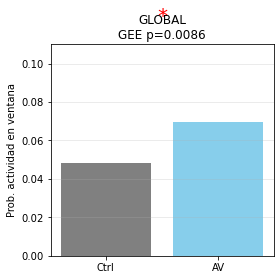


=== G1 (6–8 dpf) ===
{'p_ctrl_hat': 0.05071225720879587, 'p_av_hat': 0.06607202937095025, 'p_value': 0.14414964791600998, 'n_animales': 11, 'method': 'GEE'}


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\base\model.py:127: ValueWarning: unknown kwargs ['freq_weights']
  warnings.warn(msg, ValueWarning)


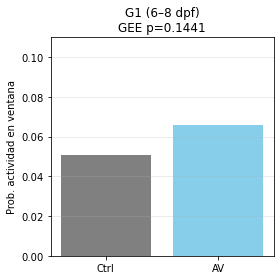


=== G2 (12–13 dpf) ===
{'p_ctrl_hat': 0.04548505271320911, 'p_av_hat': 0.07276111710047337, 'p_value': 0.03497082072728377, 'n_animales': 8, 'method': 'GEE'}


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\base\model.py:127: ValueWarning: unknown kwargs ['freq_weights']
  warnings.warn(msg, ValueWarning)


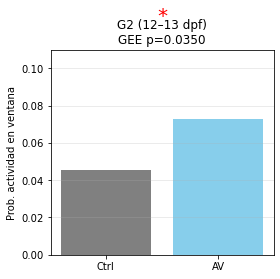


=== G3 (15–16 dpf) ===
{'p_ctrl_hat': 0.047726532567049805, 'p_av_hat': 0.07402418582375482, 'p_value': 0.3166300888548179, 'n_animales': 3, 'method': 'GEE'}


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\base\model.py:127: ValueWarning: unknown kwargs ['freq_weights']
  warnings.warn(msg, ValueWarning)


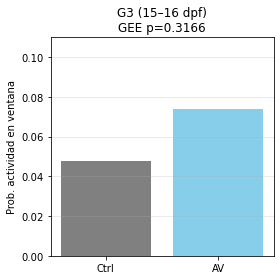

In [54]:
# ==========================================
# Comparación Ctrl vs AV en ventana de 1 s
# GEE Binomial (logit) por animal, o fallback t-test pareado
# Gráficos con "*" en diferencias significativas
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ==== Parámetros (editables) ====
ROI_KEY     = 'Hb'
FPS         = 6.25
STIM_S      = 23.3     # inicio del estímulo (s)
WIN_S       = 1.3   # duración ventana (s)
SOLO_AISLADOS = False     # usar sólo animales sociales (aislado == 0)
ALPHA       = 0.05     # umbral de significancia para marcar *

GRUPOS = {
    "G1 (6–8 dpf)":  {6, 7, 8},
    "G2 (12–13 dpf)": {12, 13},
    "G3 (15–16 dpf)": {15, 16},
}

# ==== Construir tabla por trial ====
rows = []
iterator = areas.items() if hasattr(areas, "items") else [(str(i), a) for i, a in enumerate(areas)]
a_win = int(np.floor(STIM_S * FPS))
b_win = int(np.floor((STIM_S + WIN_S) * FPS))  # exclusivo

for area_key, area in iterator:
    if  getattr(area, "aislado", None) == SOLO_AISLADOS:
        
        edad = int(getattr(area, "edad", -1))
        grupo = next((g for g, es in GRUPOS.items() if edad in es), 'FueraGrupo')

        for tr in getattr(area, "trials", []):
            rb = getattr(tr, "roi_binaries", None)
            if not (isinstance(rb, dict) and ROI_KEY in rb):
                continue
            mat = np.asarray(rb[ROI_KEY], dtype=float)
            n_neur, n_frames = mat.shape
            aa = max(0, min(a_win, n_frames - 1))
            bb = max(aa + 1, min(b_win, n_frames))
            sub = mat[:, aa:bb]
            exitos = int(sub.sum()); n = int(sub.size)

            if getattr(tr, 'vis', None) == 0 and getattr(tr, 'aud', None) == 0:
                condicion = 0
            elif getattr(tr, 'vis', None) == 1 and getattr(tr, 'aud', None) == 1:
                condicion = 1
            else:
                continue

            rows.append({
                'animal_id': str(area_key),
                'edad': edad,
                'grupo': grupo,
                'trial_id': id(tr),
                'condicion': condicion,
                'exitos': exitos,
                'n': n,
                'prop': (exitos / n) if n > 0 else np.nan,
            })

df = pd.DataFrame(rows).dropna(subset=['prop'])
if df.empty:
    raise RuntimeError("No se construyeron datos. Verificá ROI_KEY y ventana.")

print(f"Tabla: {len(df)} filas, {df['animal_id'].nunique()} animales.")

# ==== Intentar GEE ====
gee_available = True
try:
    import statsmodels.api as sm
    from statsmodels.genmod.generalized_estimating_equations import GEE
    from statsmodels.genmod.families import Binomial
    from statsmodels.genmod.cov_struct import Exchangeable
except Exception:
    gee_available = False

def fit_gee_binomial(df_fit):
    X = sm.add_constant(df_fit['condicion'].astype(float))
    y = df_fit['prop'].astype(float).values
    groups = df_fit['animal_id'].astype('category')
    gee = GEE(endog=y, exog=X, groups=groups,
              family=Binomial(), cov_struct=Exchangeable(),
              freq_weights=df_fit['n'].values)
    res = gee.fit()
    b0 = res.params['const']; b1 = res.params['condicion']
    invlogit = lambda x: 1/(1+np.exp(-x))
    return {
        'p_ctrl_hat': float(invlogit(b0)),
        'p_av_hat': float(invlogit(b0+b1)),
        'p_value': float(res.pvalues['condicion']),
        'n_animales': int(df_fit['animal_id'].nunique()),
        'method': 'GEE'
    }

def ttest_pareado_por_animal(df_fit):
    tmp = df_fit.assign(prop = df_fit['exitos']/df_fit['n'])
    piv = (tmp.groupby(['animal_id','condicion'])['prop']
              .mean()
              .unstack('condicion'))
    piv = piv.dropna()
    if piv.shape[0] >= 2:
        tval, p_two = stats.ttest_rel(piv[1].values, piv[0].values)
        return {
            'p_ctrl_hat': float(piv[0].mean()),
            'p_av_hat': float(piv[1].mean()),
            'p_value': float(p_two),
            'n_animales': int(piv.shape[0]),
            'method': 't-test'
        }
    else:
        return None

# ==== Función de plot con asterisco ====
def plot_phat(summary, title):
    p_ctrl = summary['p_ctrl_hat']; p_av = summary['p_av_hat']
    pval = summary['p_value']
    sig = pval < ALPHA
    plt.figure(figsize=(4,4))
    bars = plt.bar(['Ctrl','AV'], [p_ctrl, p_av], color=['gray','skyblue'])
    plt.ylim(0, .11)
    plt.ylabel('Prob. actividad en ventana')
    plt.title(f"{title}\n{summary['method']} p={pval:.4f}")
    if sig:
        y_max = max(p_ctrl, p_av) + 0.05
        x_mid = 0.5
        plt.text(x_mid, y_max, '*', ha='center', va='bottom', fontsize=20, color='red')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==== 3) Ajustes global y por grupo ====
resultados = {}

print("\n=== GLOBAL ===")
if gee_available:
    try:
        summ_all = fit_gee_binomial(df)
    except Exception:
        summ_all = ttest_pareado_por_animal(df)
else:
    summ_all = ttest_pareado_por_animal(df)
if summ_all:
    resultados['GLOBAL'] = summ_all
    print(summ_all)
    plot_phat(summ_all, "GLOBAL")

for gname in GRUPOS.keys():
    print(f"\n=== {gname} ===")
    df_g = df[df['grupo'] == gname]
    if df_g['animal_id'].nunique() < 2:
        print("Insuficiente")
        continue
    if gee_available:
        try:
            summ_g = fit_gee_binomial(df_g)
        except Exception:
            summ_g = ttest_pareado_por_animal(df_g)
    else:
        summ_g = ttest_pareado_por_animal(df_g)
    if summ_g:
        resultados[gname] = summ_g
        print(summ_g)
        plot_phat(summ_g, gname)


[G1 (6–8 dpf)] Ventana 23.6–24.6s  C=0.0495  AV=0.0668  Δ(AV−C)=0.0172
[G2 (12–13 dpf)] Ventana 23.6–24.6s  C=0.0465  AV=0.0793  Δ(AV−C)=0.0329
[G3 (15–16 dpf)] Ventana 23.6–24.6s  C=0.0471  AV=0.0594  Δ(AV−C)=0.0123


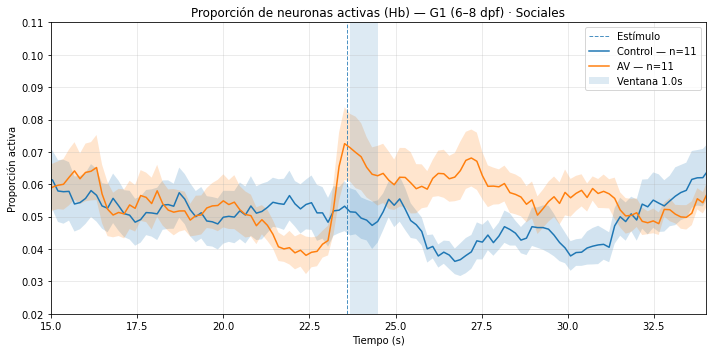

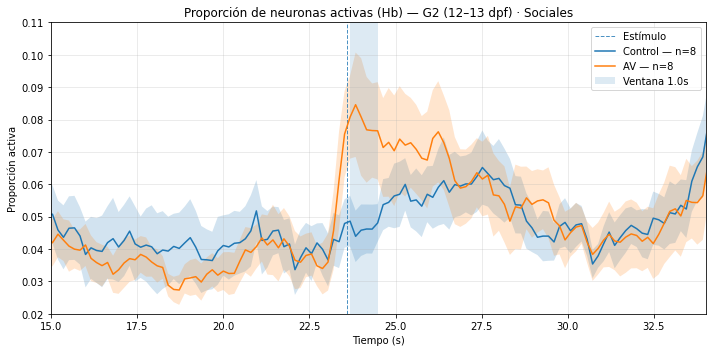

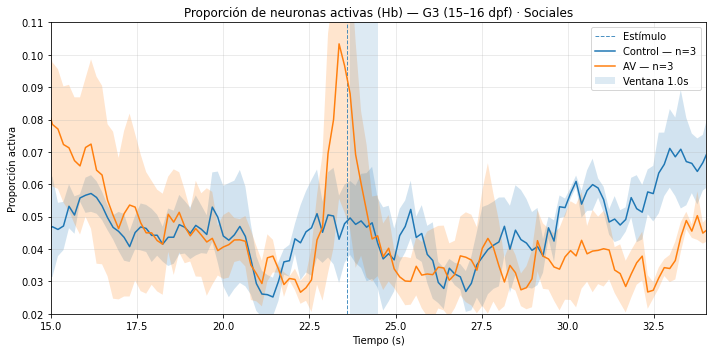

In [9]:
# === Parámetros que TENÉS que ajustar ==============================
region_key = 'Hb'
stim_s     = 23.6         # segundo del estímulo
win_s      = 1.0          # ventana post-estímulo (s)
fps        = 10.0         # <-- PONÉ TU FPS AQUÍ (float). Requerido si no hay trial.frame_times

# Grupos por edad (dpf)
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}

# === Utilidades ====================================================
os.chdir(f'H:\My Drive\Valen Agulló\SAN 2025')

def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0) == 1 and getattr(trial, 'aud', 0) == 1 else 'C'

def _trial_timebase(trial, fallback_fps):
    """
    Devuelve vector de tiempos (s) y fps para un trial.
    Usa trial.frame_times si existe; si no, usa trial.fps o fallback_fps.
    """
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, dtype=float)
        if len(ft) > 1:
            dif = np.diff(ft)
            fps_est = 1.0 / np.median(dif)
        else:
            fps_est = fallback_fps
        return ft, fps_est

    t_fps = getattr(trial, 'fps', None)
    if t_fps is None:
        if fallback_fps is None:
            raise ValueError("Definí 'fps' o proveé trial.frame_times / trial.fps.")
        t_fps = fallback_fps

    rb = getattr(trial, 'roi_binaries', None)
    if rb is None or region_key not in rb:
        raise ValueError(f"Falta roi_binaries['{region_key}'].")
    arr = np.asarray(rb[region_key])            # forma garantizada: (n_rois, n_frames)
    n_frames = arr.shape[1]
    t = np.arange(n_frames, dtype=float) / float(t_fps)
    return t, float(t_fps)

def _prop_active_per_frame(trial):
    """Proporción de neuronas activas (n_rois x n_frames → 1 x n_frames)."""
    rb = getattr(trial, 'roi_binaries', None)
    if rb is None or region_key not in rb:
        return None
    arr = np.asarray(rb[region_key])            # SIEMPRE (n_rois, n_frames)
    arr_bin = (arr > 0).astype(float)
    return arr_bin.mean(axis=0)

def _truncate_to_common_length(list_of_arrays):
    L = [len(a) for a in list_of_arrays if a is not None]
    if not L:
        return [], 0
    m = min(L)
    return [a[:m] for a in list_of_arrays if a is not None], m

def _mean_sem_over_animals(animal_traces):
    if len(animal_traces) == 0:
        return None, None
    X, L = _truncate_to_common_length(animal_traces)
    if L == 0:
        return None, None
    M = np.vstack(X)
    mean = M.mean(axis=0)
    sem  = M.std(axis=0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros_like(mean)
    return mean, sem

def _window_indices(t, t0, dur):
    return (t >= t0) & (t < t0 + dur)

# === Procesamiento: solo animales sociales =========================
social_keys = [k for k, a in areas.items() if getattr(a, 'aislado', 1) == 0]

resultados = {g: {"C": {"animals": [], "t": None}, "AV": {"animals": [], "t": None}}
              for g in grupos.keys()}

for k in social_keys:
    area = areas[k]
    edad = int(getattr(area, 'edad', -999))

    # Asignar grupo por edad
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    per_trial = {"C": [], "AV": []}
    per_time  = {"C": [], "AV": []}

    for tr in getattr(area, 'trials', []):
        cond = _get_condition(tr)
        try:
            t, tr_fps = _trial_timebase(tr, fps)
            prop = _prop_active_per_frame(tr)
            if prop is None:
                continue
            m = min(len(t), len(prop))
            per_trial[cond].append(prop[:m])
            per_time[cond].append(t[:m])
        except Exception:
            continue

    # Promedio por animal y condición
    for cond in ['C', 'AV']:
        if len(per_trial[cond]) == 0:
            continue
        series, m = _truncate_to_common_length(per_trial[cond])
        if m == 0:
            continue
        tseries, _ = _truncate_to_common_length(per_time[cond])
        t_common = tseries[0] if len(tseries) > 0 else np.arange(m) / (tr_fps if fps is None else fps)
        animal_mean = np.vstack(series).mean(axis=0)

        resultados[gname][cond]["animals"].append(animal_mean)
        if resultados[gname][cond]["t"] is None:
            resultados[gname][cond]["t"] = t_common

# === Gráficos (3 figuras: G1, G2, G3) =============================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    # Base temporal para graficar
    tC = data['C']["t"]
    tA = data['AV']["t"]
    if mean_AV is not None:
        t_plot = tA[:len(mean_AV)]
    elif mean_C is not None:
        t_plot = tC[:len(mean_C)]
    else:
        print(f"[{gname}] Sin datos.")
        continue

    w_idx = _window_indices(t_plot, stim_s, win_s)
    def _avg_win(x): return float(np.nanmean(x[w_idx])) if (x is not None and w_idx.any()) else np.nan
    avgC = _avg_win(mean_C) if mean_C is not None else np.nan
    avgA = _avg_win(mean_AV) if mean_AV is not None else np.nan
    delta = (avgA - avgC) if (not np.isnan(avgA) and not np.isnan(avgC)) else np.nan

    fig = plt.figure(figsize=(10, 5))
    plt.title(f"Proporción de neuronas activas (Hb) — {gname} · Sociales")
    if w_idx.any():
        plt.axvspan(t_plot[w_idx][0], t_plot[w_idx][-1], alpha=0.15, label=f"Ventana {win_s:.1f}s")
    plt.axvline(stim_s, linestyle='--', linewidth=1, alpha=0.8, label="Estímulo")

    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], label=f"Control — n={len(data['C']['animals'])}")
        if sem_C is not None:
            m = min(len(t_plot), len(sem_C))
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m], alpha=0.2)

    if mean_AV is not None:
        plt.plot(t_plot, mean_AV[:len(t_plot)], label=f"AV — n={len(data['AV']['animals'])}")
        if sem_AV is not None:
            m = min(len(t_plot), len(sem_AV))
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m], alpha=0.2)

    plt.xlabel("Tiempo (s)")
    plt.ylabel("Proporción activa")
    plt.ylim(.02, .11)
    plt.xlim(15, 34)
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    fig.patch.set_facecolor('white')
    # plt.savefig(f'{gname}_Sociales.png', dpi=300, bbox_inches='tight')

    print(f"[{gname}] Ventana {stim_s:.1f}–{stim_s+win_s:.1f}s  C={avgC:.4f}  AV={avgA:.4f}  Δ(AV−C)={delta:.4f}")


In [71]:
from scipy.stats import wilcoxon

# Para un grupo específico (ejemplo G1):
vals = []
G_ver =list(grupos.keys())[2]
for cond in ['C','AV']:
    # promedios por animal en la ventana
    animals = []
    for trace in resultados[G_ver][cond]['animals']:
        t = resultados[G_ver][cond]['t']
        w = (t >= stim_s) & (t < stim_s+win_s)
        animals.append(trace[w].mean())
    resultados[G_ver][cond]['win_means'] = animals

# Armo pares C y AV por animal (sólo donde hay ambos)
pairs = list(zip(resultados[G_ver]['C']['win_means'],
                 resultados[G_ver]['AV']['win_means']))
pairs = [(c,a) for c,a in pairs if not (np.isnan(c) or np.isnan(a))]
if pairs:
    c_vals, av_vals = zip(*pairs)
    stat, pval = wilcoxon(av_vals, c_vals, alternative='two-sided')
    print(f"{G_ver} Wilcoxon AV vs C: p={pval:.6g}")


G3 (15–16 dpf) Wilcoxon AV vs C: p=0.75


In [10]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def ajustar_glm_binomial_cluster(df):
    df = df.copy()
    df['prop'] = df['y'] / df['n_frames']
    df['isAV'] = (df['cond'] == 'AV').astype(int)

    # Diseñador con nombres de columnas:
    X = sm.add_constant(df[['isAV']], has_constant='add')  # columnas: ['const','isAV']
    y = df['prop'].values
    w = df['n_frames'].astype(float).values

    # cluster = neurona (pez + "_" + roi)
    clusters = (df['fish_id'].astype(str) + "_" + df['roi_id'].astype(str)).values

    glm = sm.GLM(y, X, family=sm.families.Binomial(), freq_weights=w)
    fit = glm.fit(cov_type='cluster', cov_kwds={'groups': clusters})

    beta_av = float(fit.params['isAV'])
    se_av   = float(fit.bse['isAV'])
    z       = float(fit.tvalues['isAV'])  # con cov robusta, t ≈ z
    p_two   = float(fit.pvalues['isAV'])  # <-- usá p directamente del modelo

    OR      = np.exp(beta_av)
    lo, hi  = beta_av - 1.96*se_av, beta_av + 1.96*se_av

    return {
        "beta_av": beta_av,
        "se_av":   se_av,
        "z":       z,
        "p_two":   p_two,
        "OR":      OR,
        "OR_lo":   float(np.exp(lo)),
        "OR_hi":   float(np.exp(hi)),
        "result":  fit
    }


In [14]:
def construir_df(areas, pred_grupo=None, solo_social=True):
    """
    Construye un DataFrame largo con:
    fish_id, roi_id, cond ('C'/'AV'), y (#frames activos en ventana), n_frames (en ventana),
    edad, aislado.
    Si pred_grupo es None, no filtra por edad.
    """
    rows = []
    for fish_id, area in areas.items():
        edad    = int(getattr(area, 'edad', -999))
        aislado = int(getattr(area, 'aislado', 1))
        if solo_social and aislado != 0:
            continue
        if pred_grupo is not None and not pred_grupo(edad):
            continue

        trials = getattr(area, 'trials', [])
        for tr in trials:
            cond = _get_condition(tr)
            try:
                t, _fps = _trial_timebase(tr, fps)
            except Exception:
                continue
            w = _window_mask(t, stim_s, win_s)
            if not w.any():
                continue

            rb = getattr(tr, 'roi_binaries', None)
            if rb is None or region_key not in rb:
                continue
            B = np.asarray(rb[region_key])  # (n_rois, n_frames)
            if B.ndim != 2:
                continue
            B = (B > 0).astype(np.uint8)
            n_rois = B.shape[0]
            y_vec = B[:, w].sum(axis=1)                # éxitos (frames activos) por neurona
            n_vec = np.full(n_rois, int(w.sum()))      # total de frames en ventana

            for roi_idx in range(n_rois):
                rows.append({
                    "fish_id":   str(fish_id),
                    "roi_id":    int(roi_idx),
                    "cond":      cond,
                    "y":         int(y_vec[roi_idx]),
                    "n_frames":  int(n_vec[roi_idx]),
                    "edad":      edad,
                    "aislado":   aislado
                })
    return pd.DataFrame(rows)


def _window_mask(t, t0, dur):
    """Máscara booleana para [t0, t0+dur)."""
    return (t >= t0) & (t < t0 + dur)



In [15]:
# === Inferencia: GLM Binomial con SEs robustos por neurona (cluster) ===
# Requiere: df_g con columnas ['y','n_frames','cond','fish_id','roi_id']


# === Correr por grupo (sociales) y combinado ===
solo_social = True
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}

def construir_df_simple(grupo_pred=None):
    df_g = construir_df(areas, pred_grupo=grupo_pred, solo_social=solo_social)
    # aseguramos que haya ambas condiciones
    if len(df_g)==0 or df_g['cond'].nunique()<2:
        return None
    return df_g

res_glm = {}

for gname, gpred in grupos.items():
    df_g = construir_df_simple(gpred)
    if df_g is None:
        print(f"[{gname}] Sin datos suficientes.")
        continue
    res = ajustar_glm_binomial_cluster(df_g)
    res_glm[gname] = res
    print(f"\n=== {gname} · Sociales={solo_social} ===")
    print(f"filas={len(df_g)}, peces={df_g['fish_id'].nunique()}, neuronas={(df_g['fish_id'].astype(str)+'_'+df_g['roi_id'].astype(str)).nunique()}")
    print(f"Efecto AV (log-odds): {res['beta_av']:.4f} ± {res['se_av']:.4f} [z={res['z']:.2f}, p={res['p_two']:.3g}]")
    print(f"OR={res['OR']:.3f}  IC95% OR=[{res['OR_lo']:.3f}, {res['OR_hi']:.3f}]")

# Combinado (todos los grupos etarios)
df_all = construir_df_simple(None)
if df_all is not None:
    res_all = ajustar_glm_binomial_cluster(df_all)
    res_glm["Todos"] = res_all
    print(f"\n=== Todos (combinado) · Sociales={solo_social} ===")
    print(f"filas={len(df_all)}, peces={df_all['fish_id'].nunique()}, neuronas={(df_all['fish_id'].astype(str)+'_'+df_all['roi_id'].astype(str)).nunique()}")
    print(f"Efecto AV (log-odds): {res_all['beta_av']:.4f} ± {res_all['se_av']:.4f} [z={res_all['z']:.2f}, p={res_all['p_two']:.3g}]")
    print(f"OR={res_all['OR']:.3f}  IC95% OR=[{res_all['OR_lo']:.3f}, {res_all['OR_hi']:.3f}]")
else:
    print("\n[Todos] Sin datos suficientes.")


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)



=== G1 (6–8 dpf) · Sociales=True ===
filas=14090, peces=11, neuronas=1409
Efecto AV (log-odds): 0.2620 ± 0.0672 [z=3.90, p=9.66e-05]
OR=1.299  IC95% OR=[1.139, 1.482]

=== G2 (12–13 dpf) · Sociales=True ===
filas=9390, peces=8, neuronas=939
Efecto AV (log-odds): 0.6543 ± 0.0837 [z=7.82, p=5.29e-15]
OR=1.924  IC95% OR=[1.633, 2.267]

=== G3 (15–16 dpf) · Sociales=True ===
filas=3310, peces=3, neuronas=331
Efecto AV (log-odds): 0.1920 ± 0.1542 [z=1.25, p=0.213]
OR=1.212  IC95% OR=[0.896, 1.639]

=== Todos (combinado) · Sociales=True ===
filas=26790, peces=22, neuronas=2679
Efecto AV (log-odds): 0.4035 ± 0.0497 [z=8.11, p=4.88e-16]
OR=1.497  IC95% OR=[1.358, 1.650]


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)


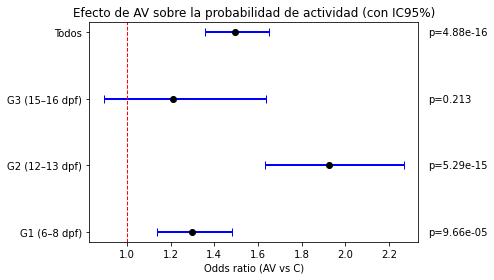

In [16]:
import matplotlib.pyplot as plt

# Orden de los grupos
order = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)", "Todos"]

# Extraigo los resultados en listas
labels, ors, lo, hi, pvals = [], [], [], [], []
for g in order:
    if g in res_glm:
        labels.append(g)
        ors.append(res_glm[g]["OR"])
        lo.append(res_glm[g]["OR_lo"])
        hi.append(res_glm[g]["OR_hi"])
        pvals.append(res_glm[g]["p_two"])

# Plot tipo forest plot
fig, ax = plt.subplots(figsize=(7,4))

y_pos = range(len(labels))
ax.errorbar(ors, y_pos, xerr=[np.array(ors)-np.array(lo), np.array(hi)-np.array(ors)],
            fmt='o', color='black', ecolor='blue', elinewidth=2, capsize=4)

# Línea de referencia en OR=1 (sin efecto)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel("Odds ratio (AV vs C)")
ax.set_title("Efecto de AV sobre la probabilidad de actividad (con IC95%)")

# Agrego los p-valores a la derecha
for y, or_, p in zip(y_pos, ors, pvals):
    ax.text(max(hi)*1.05, y, f"p={p:.3g}", va='center')

plt.tight_layout()
fig.patch.set_facecolor('white')
# plt.savefig(f'Prob_act_AV.png', dpi=300, bbox_inches='tight')
plt.show()


In [18]:
# === Hipótesis 2: “Hay más neuronas que se prenden al menos una vez en 1 s post-estímulo (AV > C)” ===
# Construye un dataset Bernoulli por neurona–trial: y_any = 1 si la neurona tuvo ≥1 frame activo en la ventana.
# Luego:
#   (A) Test pareado (Wilcoxon) por neurona: promedio de y_any en C vs AV
#   (B) GLM Binomial con SEs robustos por neurona (cluster): efecto AV vs C

# --- Parámetros ---
region_key  = 'Hb'
stim_s      = 23.6
win_s       = 1.0
fps         = 10.0        # poné el real si no hay trial.frame_times/trial.fps
solo_social = True        # filtrar a sociales

grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
    "Todos":          lambda e: True,
}

# --- Utilidades ---
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
import statsmodels.api as sm

def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0)==1 and getattr(trial, 'aud', 0)==1 else 'C'

def _trial_timebase(trial, fallback_fps):
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, dtype=float)
        fps_est = 1.0/np.median(np.diff(ft)) if len(ft)>1 else float(fallback_fps)
        return ft, float(fps_est)
    t_fps = getattr(trial, 'fps', None) or float(fallback_fps)
    n_frames = np.asarray(trial.roi_binaries[region_key]).shape[1]
    t = np.arange(n_frames, dtype=float)/float(t_fps)
    return t, float(t_fps)

def _win_mask(t, t0, dur):
    return (t >= t0) & (t < t0 + dur)

def construir_df_any(areas, pred_grupo, solo_social=True):
    rows = []
    for fish_id, area in areas.items():
        edad    = int(getattr(area, 'edad', -999))
        aislado = int(getattr(area, 'aislado', 1))
        if solo_social and aislado!=0: 
            continue
        if not pred_grupo(edad):
            continue

        for tr in getattr(area, 'trials', []):
            cond = _get_condition(tr)
            try:
                t, _ = _trial_timebase(tr, fps)
            except Exception:
                continue
            w = _win_mask(t, stim_s, win_s)
            if not w.any(): 
                continue
            rb = getattr(tr, 'roi_binaries', None)
            if rb is None or region_key not in rb:
                continue
            B = np.asarray(rb[region_key])  # (n_rois, n_frames)
            if B.ndim!=2: 
                continue
            B = (B>0).astype(np.uint8)
            y_any = (B[:, w].sum(axis=1) > 0).astype(np.uint8)  # 1 si “al menos una vez”
            n_rois = B.shape[0]
            for roi_idx in range(n_rois):
                rows.append({
                    "fish_id": str(fish_id),
                    "roi_id":  int(roi_idx),
                    "cond":    cond,           # 'C' o 'AV'
                    "y_any":   int(y_any[roi_idx]),
                    "edad":    edad,
                    "aislado": aislado
                })
    return pd.DataFrame(rows)

def wilcoxon_pareado_por_neurona(df_any):
    # Promedio de y_any por (neurona) y condición
    def _agg(grp):
        out = grp.groupby('cond')['y_any'].mean()
        return pd.Series({"C": out.get('C', np.nan), "AV": out.get('AV', np.nan)})
    paired = (df_any.groupby(['fish_id','roi_id'], as_index=False)
                   .apply(_agg)
                   .dropna())
    if len(paired)==0:
        return None, None, None
    stat, p = wilcoxon(paired['AV'], paired['C'], alternative='two-sided')
    delta_med = float((paired['AV'] - paired['C']).median())
    return stat, p, delta_med

def glm_binomial_cluster(df_any):
    # Bernoulli (y_any ∈ {0,1}); cluster = neurona (pez_roi)
    X = sm.add_constant((df_any['cond']=='AV').astype(int), has_constant='add')
    y = df_any['y_any'].astype(float).values
    clusters = (df_any['fish_id'].astype(str) + "_" + df_any['roi_id'].astype(str)).values
    glm = sm.GLM(y, X, family=sm.families.Binomial())
    fit = glm.fit(cov_type='cluster', cov_kwds={'groups': clusters})

    beta = float(fit.params[1])                # isAV
    se   = float(fit.bse[1])
    z    = float(fit.tvalues[1])               # con robusta, t ≈ z
    p    = float(fit.pvalues[1])
    OR   = float(np.exp(beta))
    lo, hi = beta - 1.96*se, beta + 1.96*se
    return {
        "beta_av": beta, "se_av": se, "z": z, "p": p,
        "OR": OR, "OR_lo": float(np.exp(lo)), "OR_hi": float(np.exp(hi)),
        "result": fit
    }

# --- Correr por grupo (incluye “Todos”) ---
res_any = {}
for gname, pred in grupos.items():
    df_g = construir_df_any(areas, pred, solo_social=solo_social)
    if df_g.empty or df_g['cond'].nunique()<2:
        print(f"[{gname}] Sin datos suficientes.")
        continue

    # (A) Wilcoxon pareado por neurona (promedio en trials)
    stat, p_wil, d_med = wilcoxon_pareado_por_neurona(df_g)
    if p_wil is not None:
        print(f"\n[{gname}] Wilcoxon (AV vs C) por neurona: n={len(df_g.groupby(['fish_id','roi_id']))}  "
              f"p={p_wil:.3g}  mediana(AV−C)={d_med:.4f}")

    # (B) GLM Binomial con cluster por neurona
    res = glm_binomial_cluster(df_g)
    res_any[gname] = res
    n_fish = df_g['fish_id'].nunique()
    n_neur = (df_g['fish_id'].astype(str)+'_'+df_g['roi_id'].astype(str)).nunique()
    print(f"[{gname}] GLM Binomial (cluster=neurona)  filas={len(df_g)}  peces={n_fish}  neuronas={n_neur}")
    print(f"   Efecto AV (log-odds) = {res['beta_av']:.4f} ± {res['se_av']:.4f}  "
          f"[z={res['z']:.2f}, p={res['p']:.3g}]  →  OR={res['OR']:.3f}  "
          f"IC95% OR=[{res['OR_lo']:.3f}, {res['OR_hi']:.3f}]")



[G1 (6–8 dpf)] Wilcoxon (AV vs C) por neurona: n=1409  p=0.0153  mediana(AV−C)=0.0000
[G1 (6–8 dpf)] GLM Binomial (cluster=neurona)  filas=14090  peces=11  neuronas=1409
   Efecto AV (log-odds) = 0.1881 ± 0.0593  [z=3.17, p=0.00151]  →  OR=1.207  IC95% OR=[1.075, 1.356]

[G2 (12–13 dpf)] Wilcoxon (AV vs C) por neurona: n=939  p=8.22e-12  mediana(AV−C)=0.0000
[G2 (12–13 dpf)] GLM Binomial (cluster=neurona)  filas=9390  peces=8  neuronas=939
   Efecto AV (log-odds) = 0.5368 ± 0.0697  [z=7.70, p=1.34e-14]  →  OR=1.711  IC95% OR=[1.492, 1.961]

[G3 (15–16 dpf)] Wilcoxon (AV vs C) por neurona: n=331  p=0.183  mediana(AV−C)=0.0000
[G3 (15–16 dpf)] GLM Binomial (cluster=neurona)  filas=3310  peces=3  neuronas=331
   Efecto AV (log-odds) = 0.3005 ± 0.1384  [z=2.17, p=0.0299]  →  OR=1.351  IC95% OR=[1.030, 1.771]

[Todos] Wilcoxon (AV vs C) por neurona: n=2679  p=3.76e-11  mediana(AV−C)=0.0000
[Todos] GLM Binomial (cluster=neurona)  filas=26790  peces=22  neuronas=2679
   Efecto AV (log-odds) 

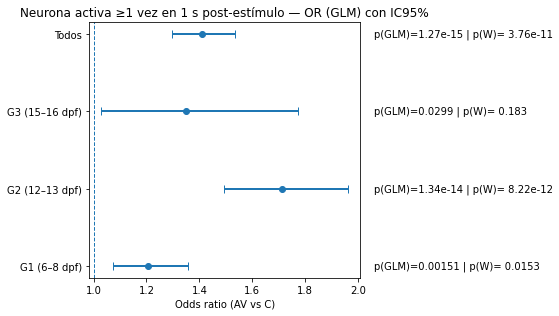

In [ ]:
# === Forest plot de la hipótesis “al menos una vez en 1 s” (AV vs C) ===
# Muestra OR (GLM binomial con cluster=neurona) con IC95% por grupo
# y anota el p-valor de Wilcoxon por neurona al costado.

# -------------------------------------------------------------------
# Si ya corriste el bloque que calcula res_any (GLM) y usaste
# wilcoxon_pareado_por_neurona(...) por grupo, podés construir
# este diccionario acá. Si no, armamos los p-val de Wilcoxon ahora:
# -------------------------------------------------------------------
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
    "Todos":          lambda e: True,
}

# Asegurate de tener estas funciones del bloque anterior:
#  - construir_df_any(areas, pred_grupo, solo_social=True)
#  - wilcoxon_pareado_por_neurona(df_any)
# Y el diccionario res_any, con estructura:
#    res_any[g]["OR"], ["OR_lo"], ["OR_hi"], ["p"], etc.

solo_social = True

wilcoxon_pvals = {}
for gname, pred in grupos.items():
    df_g = construir_df_any(areas, pred, solo_social=solo_social)
    if df_g.empty or df_g['cond'].nunique() < 2:
        continue
    _, p_wil, _ = wilcoxon_pareado_por_neurona(df_g)
    wilcoxon_pvals[gname] = p_wil

# -------------------------------------------------------------------
# Armar datos para el forest plot (usa res_any del paso anterior)
# -------------------------------------------------------------------
order = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)", "Todos"]

labels, ors, lo, hi, p_glm, p_wil_list = [], [], [], [], [], []
for g in order:
    if g in res_any:
        labels.append(g)
        ors.append(res_any[g]["OR"])
        lo.append(res_any[g]["OR_lo"])
        hi.append(res_any[g]["OR_hi"])
        p_glm.append(res_any[g]["p"])
        p_wil_list.append(wilcoxon_pvals.get(g, np.nan))

ors = np.array(ors, float)
lo  = np.array(lo, float)
hi  = np.array(hi, float)

# -------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))

y = np.arange(len(labels))
xerr = np.vstack([ors - lo, hi - ors])

ax.errorbar(ors, y, xerr=xerr, fmt='o', ecolor='tab:blue', capsize=4, elinewidth=2)
ax.axvline(1.0, linestyle='--', linewidth=1)  # referencia (sin efecto)

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Odds ratio (AV vs C)")
ax.set_title("Neurona activa ≥1 vez en 1 s post-estímulo — OR (GLM) con IC95%")

# Anotar p-valores (GLM y Wilcoxon) a la derecha
x_text = max(hi) * 1.05
for yi, (pg, pw) in enumerate(zip(p_glm, p_wil_list)):
    ax.text(x_text, yi, f"p(GLM)={pg:.3g} | p(W)= {pw:.3g}", va='center')

plt.tight_layout()
fig.patch.set_facecolor('white')
# plt.savefig(f'Prob_act_al_menos_una_vez_AV_Sociales.png', dpi=300, bbox_inches='tight')
plt.show()




In [81]:
# Construir dataset sólo con G1 y G2
df_g1 = construir_df_any(areas, grupos["G1 (6–8 dpf)"], solo_social=True)
df_g2 = construir_df_any(areas, grupos["G2 (12–13 dpf)"], solo_social=True)
df_sub = pd.concat([df_g1, df_g2], ignore_index=True)

# Codificación de variables
df_sub['isAV'] = (df_sub['cond'] == 'AV').astype(int)
df_sub['grupo'] = np.where(df_sub['edad'].between(12,13), 'G2', 'G1')
df_sub['isG2'] = (df_sub['grupo'] == 'G2').astype(int)

# Diseño con interacción
X = pd.DataFrame({
    "const": 1,
    "isAV": df_sub['isAV'],
    "isG2": df_sub['isG2'],
    "AVxG2": df_sub['isAV'] * df_sub['isG2']
})
y = df_sub['y_any'].astype(float).values

# Cluster = neurona
clusters = (df_sub['fish_id'].astype(str) + "_" + df_sub['roi_id'].astype(str)).values

glm = sm.GLM(y, X, family=sm.families.Binomial())
fit = glm.fit(cov_type='cluster', cov_kwds={'groups': clusters})

print(fit.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                23480
Model:                            GLM   Df Residuals:                    23476
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8291.8
Date:                Tue, 09 Sep 2025   Deviance:                       16584.
Time:                        13:27:23   Pearson chi2:                 2.35e+04
No. Iterations:                     5   Pseudo R-squ. (CS):           0.007508
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3051      0.043    -53.722      0.0

=== Comparación G2 (12–13) vs G1 (6–8) · Sociales=False ===
filas=23480  peces=19  neuronas=2348

AV en G1:  OR=1.207  IC95%=[1.075, 1.356]  p=0.00151
AV en G2:  OR=1.711  IC95%=[1.492, 1.961]
Dif G2 vs G1 (interacción): OR_rel=1.417  IC95%=[1.185, 1.696]  p=0.000138


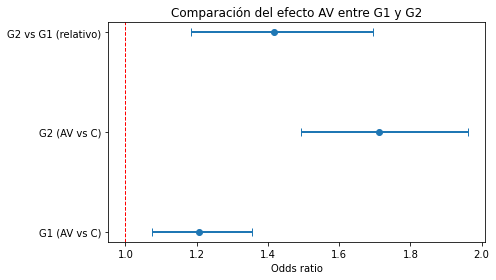

In [ ]:
# === Comparación estadística del efecto AV entre G2 (12–13 dpf) y G1 (6–8 dpf) ===
# Usa el enfoque con interacción: isAV, isG2 y AVxG2.
# Requiere que ya tengas definidas: construir_df_any, grupos, y que tengas importado sm, np, pd, plt (si graficás).

# 1) Armar datos (solo sociales, G1 y G2)
df_g1 = construir_df_any(areas, grupos["G1 (6–8 dpf)"], solo_social=True)
df_g2 = construir_df_any(areas, grupos["G2 (12–13 dpf)"], solo_social=True)
df_sub = pd.concat([df_g1, df_g2], ignore_index=True)

# 2) Codificación y matriz de diseño con interacción
df_sub['isAV'] = (df_sub['cond'] == 'AV').astype(int)
df_sub['isG2'] = ((df_sub['edad'] >= 12) & (df_sub['edad'] <= 13)).astype(int)
X = pd.DataFrame({
    "const": 1,
    "isAV":  df_sub['isAV'],
    "isG2":  df_sub['isG2'],
    "AVxG2": df_sub['isAV'] * df_sub['isG2'],
})
y = df_sub['y_any'].astype(float).values
clusters = (df_sub['fish_id'].astype(str) + "_" + df_sub['roi_id'].astype(str)).values

# 3) Ajuste GLM binomial con covarianzas robustas agrupadas por neurona
glm = sm.GLM(y, X, family=sm.families.Binomial())
fit = glm.fit(cov_type='cluster', cov_kwds={'groups': clusters})

# 4) Extraer efectos y construir OR + IC95% correctamente (incluyendo covarianza)
params = fit.params
bse    = fit.bse
V      = fit.cov_params()  # matriz de covarianzas robusta

# AV en G1 (grupo base)
beta_g1 = params['isAV']
se_g1   = bse['isAV']
OR_g1   = np.exp(beta_g1)
ci_g1   = np.exp([beta_g1 - 1.96*se_g1, beta_g1 + 1.96*se_g1])
p_g1    = fit.pvalues['isAV']

# AV en G2 = isAV + AVxG2 (usar varianza compuesta con covarianza)
beta_g2 = params['isAV'] + params['AVxG2']
var_g2  = V.loc['isAV','isAV'] + V.loc['AVxG2','AVxG2'] + 2*V.loc['isAV','AVxG2']
se_g2   = np.sqrt(var_g2)
OR_g2   = np.exp(beta_g2)
ci_g2   = np.exp([beta_g2 - 1.96*se_g2, beta_g2 + 1.96*se_g2])

# Interacción (diferencia de efectos: G2 vs G1)
beta_int = params['AVxG2']
se_int   = bse['AVxG2']
OR_int   = np.exp(beta_int)  # “cuántas veces” es mayor el efecto en G2 vs G1
ci_int   = np.exp([beta_int - 1.96*se_int, beta_int + 1.96*se_int])
p_int    = fit.pvalues['AVxG2']

# 5) Imprimir resumen claro
n_fish = df_sub['fish_id'].nunique()
n_neur = (df_sub['fish_id'].astype(str)+'_'+df_sub['roi_id'].astype(str)).nunique()
print(f"=== Comparación G2 (12–13) vs G1 (6–8) · Sociales=True ===")
print(f"filas={len(df_sub)}  peces={n_fish}  neuronas={n_neur}\n")

print(f"AV en G1:  OR={OR_g1:.3f}  IC95%=[{ci_g1[0]:.3f}, {ci_g1[1]:.3f}]  p={p_g1:.3g}")
print(f"AV en G2:  OR={OR_g2:.3f}  IC95%=[{ci_g2[0]:.3f}, {ci_g2[1]:.3f}]")
print(f"Dif G2 vs G1 (interacción): OR_rel={OR_int:.3f}  IC95%=[{ci_int[0]:.3f}, {ci_int[1]:.3f}]  p={p_int:.3g}")

# 6) (Opcional) Forest plot: OR G1, OR G2 y OR relativo de la interacción
labels = ["G1 (AV vs C)", "G2 (AV vs C)", "G2 vs G1 (relativo)"]
ors    = np.array([OR_g1, OR_g2, OR_int], dtype=float)
lo     = np.array([ci_g1[0], ci_g2[0], ci_int[0]], dtype=float)
hi     = np.array([ci_g1[1], ci_g2[1], ci_int[1]], dtype=float)
y_pos  = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(7,4))
ax.errorbar(ors, y_pos, xerr=[ors - lo, hi - ors], fmt='o', ecolor='tab:blue', elinewidth=2, capsize=4)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1)
ax.set_yticks(y_pos); ax.set_yticklabels(labels)
ax.set_xlabel("Odds ratio"); ax.set_title("Comparación del efecto AV entre G1 y G2")
plt.tight_layout(); plt.show()


[G1 (6–8 dpf)] Sin datos.
[G2 (12–13 dpf)] Ventana 23.6–24.6s  C=0.0475  AV=0.0828  Δ(AV−C)=0.0353
[G3 (15–16 dpf)] Sin datos.


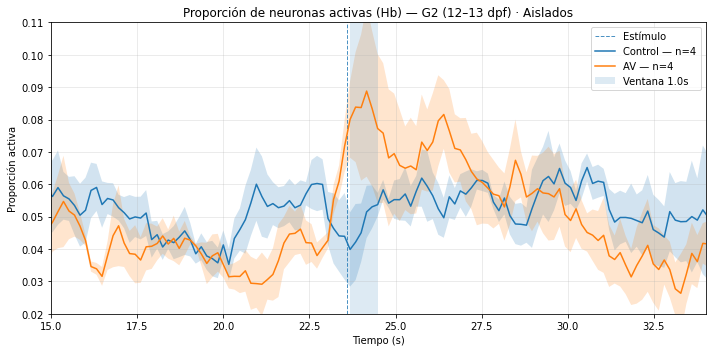

In [6]:
# === Parámetros que TENÉS que ajustar ==============================
region_key = 'Hb'
stim_s     = 23.6         # segundo del estímulo
win_s      = 1.0          # ventana post-estímulo (s)
fps        = 10.0         # <-- PONÉ TU FPS AQUÍ (float). Requerido si no hay trial.frame_times

# Grupos por edad (dpf)
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}

# === Utilidades ====================================================


def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0) == 1 and getattr(trial, 'aud', 0) == 1 else 'C'

def _trial_timebase(trial, fallback_fps):
    """
    Devuelve vector de tiempos (s) y fps para un trial.
    Usa trial.frame_times si existe; si no, usa trial.fps o fallback_fps.
    """
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, dtype=float)
        if len(ft) > 1:
            dif = np.diff(ft)
            fps_est = 1.0 / np.median(dif)
        else:
            fps_est = fallback_fps
        return ft, fps_est

    t_fps = getattr(trial, 'fps', None)
    if t_fps is None:
        if fallback_fps is None:
            raise ValueError("Definí 'fps' o proveé trial.frame_times / trial.fps.")
        t_fps = fallback_fps

    rb = getattr(trial, 'roi_binaries', None)
    if rb is None or region_key not in rb:
        raise ValueError(f"Falta roi_binaries['{region_key}'].")
    arr = np.asarray(rb[region_key])            # forma garantizada: (n_rois, n_frames)
    n_frames = arr.shape[1]
    t = np.arange(n_frames, dtype=float) / float(t_fps)
    return t, float(t_fps)

def _prop_active_per_frame(trial):
    """Proporción de neuronas activas (n_rois x n_frames → 1 x n_frames)."""
    rb = getattr(trial, 'roi_binaries', None)
    if rb is None or region_key not in rb:
        return None
    arr = np.asarray(rb[region_key])            # SIEMPRE (n_rois, n_frames)
    arr_bin = (arr > 0).astype(float)
    return arr_bin.mean(axis=0)

def _truncate_to_common_length(list_of_arrays):
    L = [len(a) for a in list_of_arrays if a is not None]
    if not L:
        return [], 0
    m = min(L)
    return [a[:m] for a in list_of_arrays if a is not None], m

def _mean_sem_over_animals(animal_traces):
    if len(animal_traces) == 0:
        return None, None
    X, L = _truncate_to_common_length(animal_traces)
    if L == 0:
        return None, None
    M = np.vstack(X)
    mean = M.mean(axis=0)
    sem  = M.std(axis=0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros_like(mean)
    return mean, sem

def _window_indices(t, t0, dur):
    return (t >= t0) & (t < t0 + dur)

# === Procesamiento: solo animales sociales =========================
social_keys = [k for k, a in areas.items() if getattr(a, 'aislado', -1) == 1]

resultados = {g: {"C": {"animals": [], "t": None}, "AV": {"animals": [], "t": None}}
              for g in grupos.keys()}

for k in social_keys:
    area = areas[k]
    edad = int(getattr(area, 'edad', -999))

    # Asignar grupo por edad
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    per_trial = {"C": [], "AV": []}
    per_time  = {"C": [], "AV": []}

    for tr in getattr(area, 'trials', []):
        cond = _get_condition(tr)
        try:
            t, tr_fps = _trial_timebase(tr, fps)
            prop = _prop_active_per_frame(tr)
            if prop is None:
                continue
            m = min(len(t), len(prop))
            per_trial[cond].append(prop[:m])
            per_time[cond].append(t[:m])
        except Exception:
            continue

    # Promedio por animal y condición
    for cond in ['C', 'AV']:
        if len(per_trial[cond]) == 0:
            continue
        series, m = _truncate_to_common_length(per_trial[cond])
        if m == 0:
            continue
        tseries, _ = _truncate_to_common_length(per_time[cond])
        t_common = tseries[0] if len(tseries) > 0 else np.arange(m) / (tr_fps if fps is None else fps)
        animal_mean = np.vstack(series).mean(axis=0)

        resultados[gname][cond]["animals"].append(animal_mean)
        if resultados[gname][cond]["t"] is None:
            resultados[gname][cond]["t"] = t_common

# === Gráficos (3 figuras: G1, G2, G3) =============================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    # Base temporal para graficar
    tC = data['C']["t"]
    tA = data['AV']["t"]
    if mean_AV is not None:
        t_plot = tA[:len(mean_AV)]
    elif mean_C is not None:
        t_plot = tC[:len(mean_C)]
    else:
        print(f"[{gname}] Sin datos.")
        continue

    w_idx = _window_indices(t_plot, stim_s, win_s)
    def _avg_win(x): return float(np.nanmean(x[w_idx])) if (x is not None and w_idx.any()) else np.nan
    avgC = _avg_win(mean_C) if mean_C is not None else np.nan
    avgA = _avg_win(mean_AV) if mean_AV is not None else np.nan
    delta = (avgA - avgC) if (not np.isnan(avgA) and not np.isnan(avgC)) else np.nan

    fig = plt.figure(figsize=(10, 5))
    plt.title(f"Proporción de neuronas activas (Hb) — {gname} · Aislados")
    if w_idx.any():
        plt.axvspan(t_plot[w_idx][0], t_plot[w_idx][-1], alpha=0.15, label=f"Ventana {win_s:.1f}s")
    plt.axvline(stim_s, linestyle='--', linewidth=1, alpha=0.8, label="Estímulo")

    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], label=f"Control — n={len(data['C']['animals'])}")
        if sem_C is not None:
            m = min(len(t_plot), len(sem_C))
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m], alpha=0.2)

    if mean_AV is not None:
        plt.plot(t_plot, mean_AV[:len(t_plot)], label=f"AV — n={len(data['AV']['animals'])}")
        if sem_AV is not None:
            m = min(len(t_plot), len(sem_AV))
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m], alpha=0.2)

    plt.xlabel("Tiempo (s)")
    plt.ylabel("Proporción activa")
    plt.ylim(.02, .11)
    plt.xlim(15, 34)
    fig.patch.set_facecolor('white')

    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    # plt.savefig(f'G2 (12-13)_Aislados.png', dpi=300, bbox_inches='tight')
    print(f"[{gname}] Ventana {stim_s:.1f}–{stim_s+win_s:.1f}s  C={avgC:.4f}  AV={avgA:.4f}  Δ(AV−C)={delta:.4f}")


In [124]:
# ================== (A) Proporción por frame — Aislados ==================
solo_social = False  # importante: NO filtrar sociales en construir_df
grupos_ais = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
    "Todos":          lambda e: True,
}

print("\n=== Proporción por frame — Animales AISLADOS ===")
for gname, pred in grupos_ais.items():
    df_g = construir_df(areas, pred_grupo=pred, solo_social=solo_social)
    if df_g.empty or df_g['cond'].nunique() < 2:
        print(f"[{gname}] Sin datos suficientes.")
        continue
    # filtrar aislados
    df_g = df_g[df_g['aislado'] == 1].copy()
    if df_g.empty or df_g['cond'].nunique() < 2:
        print(f"[{gname}] Sin datos suficientes (aislados).")
        continue

    res = ajustar_glm_binomial_cluster(df_g)  # misma función que usamos antes
    n_fish = df_g['fish_id'].nunique()
    n_neur = (df_g['fish_id'].astype(str)+'_'+df_g['roi_id'].astype(str)).nunique()
    print(f"[{gname}] filas={len(df_g)}  peces={n_fish}  neuronas={n_neur}")
    print(f"   Efecto AV (log-odds) = {res['beta_av']:.4f} ± {res['se_av']:.4f}  "
          f"[z={res['z']:.2f}, p={res['p_two']:.3g}]  →  OR={res['OR']:.3f}  "
          f"IC95% OR=[{res['OR_lo']:.3f}, {res['OR_hi']:.3f}]")

# ============== (B) “Al menos una vez” — Aislados =================
print("\n=== 'Al menos una vez en 1 s' — Animales AISLADOS ===")
for gname, pred in grupos_ais.items():
    df_any = construir_df_any(areas, pred_grupo=pred, solo_social=solo_social)
    if df_any.empty or df_any['cond'].nunique() < 2:
        print(f"[{gname}] Sin datos suficientes.")
        continue
    # filtrar aislados
    df_any = df_any[df_any['aislado'] == 1].copy()
    if df_any.empty or df_any['cond'].nunique() < 2:
        print(f"[{gname}] Sin datos suficientes (aislados).")
        continue

    # Wilcoxon pareado por neurona (promedio en trials)
    stat, p_wil, d_med = wilcoxon_pareado_por_neurona(df_any)
    if p_wil is not None:
        print(f"[{gname}] Wilcoxon (AV vs C) por neurona: n={len(df_any.groupby(['fish_id','roi_id']))}  "
              f"p={p_wil:.3g}  mediana(AV−C)={d_med:.4f}")

    # GLM Binomial con cluster=neurona
    res = glm_binomial_cluster(df_any)
    n_fish = df_any['fish_id'].nunique()
    n_neur = (df_any['fish_id'].astype(str)+'_'+df_any['roi_id'].astype(str)).nunique()
    print(f"[{gname}] GLM Binomial (cluster=neurona)  filas={len(df_any)}  peces={n_fish}  neuronas={n_neur}")
    print(f"   Efecto AV (log-odds) = {res['beta_av']:.4f} ± {res['se_av']:.4f}  "
          f"[z={res['z']:.2f}, p={res['p']:.3g}]  →  OR={res['OR']:.3f}  "
          f"IC95% OR=[{res['OR_lo']:.3f}, {res['OR_hi']:.3f}]")



=== Proporción por frame — Animales AISLADOS ===
[G1 (6–8 dpf)] Sin datos suficientes (aislados).
[G2 (12–13 dpf)] filas=4390  peces=4  neuronas=439
   Efecto AV (log-odds) = 0.5631 ± 0.1112  [z=5.06, p=4.15e-07]  →  OR=1.756  IC95% OR=[1.412, 2.184]
[G3 (15–16 dpf)] Sin datos suficientes (aislados).


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)


[Todos] filas=4390  peces=4  neuronas=439
   Efecto AV (log-odds) = 0.5631 ± 0.1112  [z=5.06, p=4.15e-07]  →  OR=1.756  IC95% OR=[1.412, 2.184]

=== 'Al menos una vez en 1 s' — Animales AISLADOS ===
[G1 (6–8 dpf)] Sin datos suficientes (aislados).
[G2 (12–13 dpf)] Wilcoxon (AV vs C) por neurona: n=439  p=1.01e-06  mediana(AV−C)=0.0000
[G2 (12–13 dpf)] GLM Binomial (cluster=neurona)  filas=4390  peces=4  neuronas=439
   Efecto AV (log-odds) = 0.5179 ± 0.0959  [z=5.40, p=6.67e-08]  →  OR=1.679  IC95% OR=[1.391, 2.026]
[G3 (15–16 dpf)] Sin datos suficientes (aislados).
[Todos] Wilcoxon (AV vs C) por neurona: n=439  p=1.01e-06  mediana(AV−C)=0.0000
[Todos] GLM Binomial (cluster=neurona)  filas=4390  peces=4  neuronas=439
   Efecto AV (log-odds) = 0.5179 ± 0.0959  [z=5.40, p=6.67e-08]  →  OR=1.679  IC95% OR=[1.391, 2.026]


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)


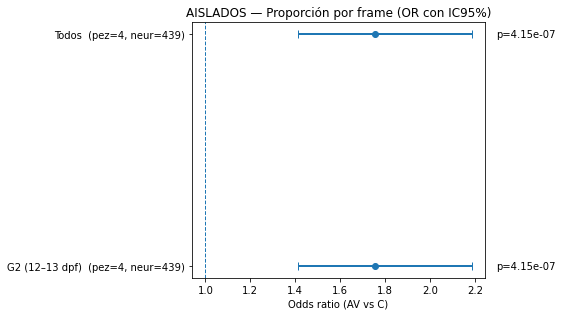

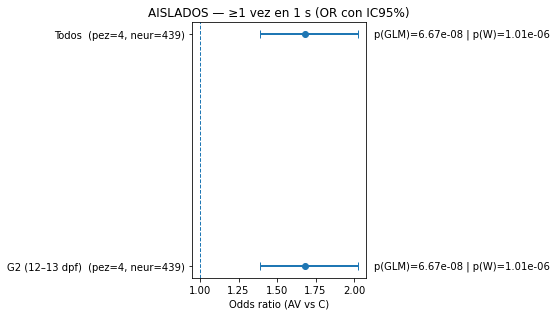

In [19]:
# === Forest plots para AISLADOS (mismo análisis, ahora graficado) ===
# Reutiliza: construir_df, ajustar_glm_binomial_cluster, construir_df_any,
#            wilcoxon_pareado_por_neurona, glm_binomial_cluster
# No importa librerías nuevas.

solo_social = False  # AISLADOS
grupos_ais = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
    "Todos":          lambda e: True,
}

# ---------------- (A) Proporción por frame ----------------
res_frame = {}
labels_A, ORs_A, LO_A, HI_A, P_A, Ns_A = [], [], [], [], [], []

for gname, pred in grupos_ais.items():
    df_g = construir_df(areas, pred_grupo=pred, solo_social=solo_social)
    if df_g.empty: 
        continue
    df_g = df_g[df_g['aislado'] == 1]
    if df_g.empty or df_g['cond'].nunique() < 2:
        continue
    r = ajustar_glm_binomial_cluster(df_g)
    res_frame[gname] = r
    labels_A.append(gname)
    ORs_A.append(r["OR"]); LO_A.append(r["OR_lo"]); HI_A.append(r["OR_hi"])
    P_A.append(r["p_two"])
    Ns_A.append((df_g['fish_id'].nunique(), (df_g['fish_id'].astype(str)+'_'+df_g['roi_id'].astype(str)).nunique()))

# Plot (A)
y = np.arange(len(labels_A))
xerr = np.vstack([np.array(ORs_A) - np.array(LO_A), np.array(HI_A) - np.array(ORs_A)])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(ORs_A, y, xerr=xerr, fmt='o', ecolor='tab:blue', elinewidth=2, capsize=4)
ax.axvline(1.0, linestyle='--', linewidth=1)
ax.set_yticks(y); ax.set_yticklabels([f"{lab}  (pez={n[0]}, neur={n[1]})" for lab, n in zip(labels_A, Ns_A)])
ax.set_xlabel("Odds ratio (AV vs C)"); ax.set_title("AISLADOS — Proporción por frame (OR con IC95%)")
x_txt = max(HI_A) * 1.05
for yi, p in enumerate(P_A):
    ax.text(x_txt, yi, f"p={p:.3g}", va='center')
fig.patch.set_facecolor('white')
# plt.savefig(f'Prob_act_AV_Aislados.png', dpi=300, bbox_inches='tight')
plt.tight_layout(); plt.show()

# ---------------- (B) “Al menos una vez” ----------------
res_any_plot = {}
labels_B, ORs_B, LO_B, HI_B, Pglm_B, Pw_B, Ns_B = [], [], [], [], [], [], []

for gname, pred in grupos_ais.items():
    df_any = construir_df_any(areas, pred, solo_social=solo_social)
    if df_any.empty:
        continue
    df_any = df_any[df_any['aislado'] == 1]
    if df_any.empty or df_any['cond'].nunique() < 2:
        continue

    # Wilcoxon
    _, p_wil, _ = wilcoxon_pareado_por_neurona(df_any)
    # GLM cluster
    r = glm_binomial_cluster(df_any)
    res_any_plot[gname] = (r, p_wil)

    labels_B.append(gname)
    ORs_B.append(r["OR"]); LO_B.append(r["OR_lo"]); HI_B.append(r["OR_hi"])
    Pglm_B.append(r["p"]); Pw_B.append(p_wil if p_wil is not None else np.nan)
    Ns_B.append((df_any['fish_id'].nunique(), (df_any['fish_id'].astype(str)+'_'+df_any['roi_id'].astype(str)).nunique()))

# Plot (B)
y = np.arange(len(labels_B))
xerr = np.vstack([np.array(ORs_B) - np.array(LO_B), np.array(HI_B) - np.array(ORs_B)])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(ORs_B, y, xerr=xerr, fmt='o', ecolor='tab:blue', elinewidth=2, capsize=4)
ax.axvline(1.0, linestyle='--', linewidth=1)
ax.set_yticks(y); ax.set_yticklabels([f"{lab}  (pez={n[0]}, neur={n[1]})" for lab, n in zip(labels_B, Ns_B)])
ax.set_xlabel("Odds ratio (AV vs C)"); ax.set_title("AISLADOS — ≥1 vez en 1 s (OR con IC95%)")
x_txt = max(HI_B) * 1.05
for yi, (pg, pw) in enumerate(zip(Pglm_B, Pw_B)):
    ax.text(x_txt, yi, f"p(GLM)={pg:.3g} | p(W)={pw:.3g}", va='center')


plt.tight_layout(); plt.show()


=== Comparación G2 (12–13 dpf): Aislados vs Sociales ===
filas=13780  peces=12  neuronas=1378

AV en Sociales: OR=1.711  IC95%=[1.492, 1.961]  p=1.33e-14
AV en Aislados: OR=1.679  IC95%=[1.391, 2.025]
Dif Aislados vs Sociales (interacción): OR_rel=0.981  IC95%=[0.778, 1.238]  p=0.873


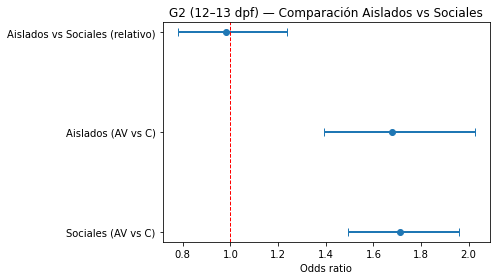

In [20]:
# === Comparación G2 aislados vs sociales ===

# 1) Construir datasets
df_g2_soc = construir_df_any(areas, grupos["G2 (12–13 dpf)"], solo_social=True)
df_g2_iso = construir_df_any(areas, grupos["G2 (12–13 dpf)"], solo_social=False)
df_g2_iso = df_g2_iso[df_g2_iso['aislado'] == 1]  # sólo aislados
df_sub = pd.concat([df_g2_soc, df_g2_iso], ignore_index=True)

# 2) Variables
df_sub['isAV'] = (df_sub['cond'] == 'AV').astype(int)
df_sub['isIso'] = (df_sub['aislado'] == 1).astype(int)

X = pd.DataFrame({
    "const": 1,
    "isAV": df_sub['isAV'],
    "isIso": df_sub['isIso'],
    "AVxIso": df_sub['isAV'] * df_sub['isIso'],
})
y = df_sub['y_any'].astype(float).values
clusters = (df_sub['fish_id'].astype(str) + "_" + df_sub['roi_id'].astype(str)).values

# 3) Ajustar modelo
glm = sm.GLM(y, X, family=sm.families.Binomial())
fit = glm.fit(cov_type='cluster', cov_kwds={'groups': clusters})

# 4) Extraer resultados
params = fit.params; bse = fit.bse; V = fit.cov_params()

# Sociales (referencia)
beta_soc = params['isAV']; se_soc = bse['isAV']
OR_soc = np.exp(beta_soc)
ci_soc = np.exp([beta_soc - 1.96*se_soc, beta_soc + 1.96*se_soc])
p_soc = fit.pvalues['isAV']

# Aislados = isAV + AVxIso
beta_iso = params['isAV'] + params['AVxIso']
var_iso = V.loc['isAV','isAV'] + V.loc['AVxIso','AVxIso'] + 2*V.loc['isAV','AVxIso']
se_iso = np.sqrt(var_iso)
OR_iso = np.exp(beta_iso)
ci_iso = np.exp([beta_iso - 1.96*se_iso, beta_iso + 1.96*se_iso])

# Interacción (diferencia aislados vs sociales)
beta_int = params['AVxIso']; se_int = bse['AVxIso']
OR_int = np.exp(beta_int)
ci_int = np.exp([beta_int - 1.96*se_int, beta_int + 1.96*se_int])
p_int = fit.pvalues['AVxIso']

# 5) Reporte
n_fish = df_sub['fish_id'].nunique()
n_neur = (df_sub['fish_id'].astype(str)+'_'+df_sub['roi_id'].astype(str)).nunique()
print(f"=== Comparación G2 (12–13 dpf): Aislados vs Sociales ===")
print(f"filas={len(df_sub)}  peces={n_fish}  neuronas={n_neur}\n")

print(f"AV en Sociales: OR={OR_soc:.3f}  IC95%=[{ci_soc[0]:.3f}, {ci_soc[1]:.3f}]  p={p_soc:.3g}")
print(f"AV en Aislados: OR={OR_iso:.3f}  IC95%=[{ci_iso[0]:.3f}, {ci_iso[1]:.3f}]")
print(f"Dif Aislados vs Sociales (interacción): OR_rel={OR_int:.3f}  "
      f"IC95%=[{ci_int[0]:.3f}, {ci_int[1]:.3f}]  p={p_int:.3g}")

# 6) Forest plot comparativo
labels = ["Sociales (AV vs C)", "Aislados (AV vs C)", "Aislados vs Sociales (relativo)"]
ors = np.array([OR_soc, OR_iso, OR_int], float)
lo  = np.array([ci_soc[0], ci_iso[0], ci_int[0]], float)
hi  = np.array([ci_soc[1], ci_iso[1], ci_int[1]], float)
y_pos = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(7,4))
ax.errorbar(ors, y_pos, xerr=[ors-lo, hi-ors], fmt='o', ecolor='tab:blue', elinewidth=2, capsize=4)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1)
ax.set_yticks(y_pos); ax.set_yticklabels(labels)
ax.set_xlabel("Odds ratio"); ax.set_title("G2 (12–13 dpf) — Comparación Aislados vs Sociales")
plt.tight_layout(); plt.show()


In [39]:
# getattr(tr, 'roi_binaries', None)
rb = getattr(tr, 'roi_binaries', None)


In [44]:
rb[region_key][:,60:].shape

(144, 155)

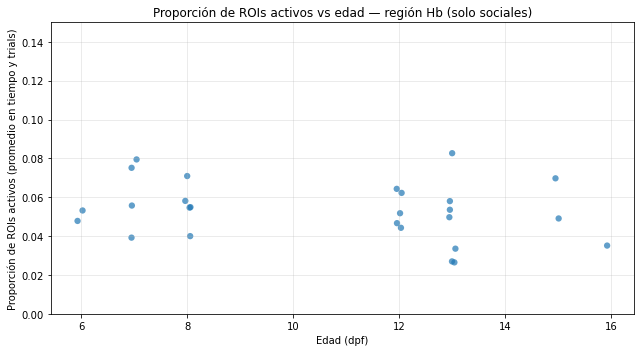

In [45]:
# === Parámetros que podés ajustar =================================
region_key      = 'Hb'    # región anatómica
solo_sociales   = True    # True => usa solo animales sociales (aislado==0); False => usa todos

# === Utilidades ====================================================
import numpy as np
import matplotlib.pyplot as plt

def _prop_activa_por_frame(binaries_2d):
    """binaries_2d: (n_rois, n_frames) con 0/1 -> proporción de ROIs activos por frame: (n_frames,)"""
    return np.nanmean(binaries_2d, axis=0)

def _prom_animal_en_trials(area, region_key):
    """
    Para un animal (área): calcula la métrica Y solicitada = promedio (en el tiempo y trials)
    de la proporción de ROIs activos por frame.
    Retorna escalar (float) o None si no hay datos.
    """
    vals = []
    for tr in getattr(area, 'trials', []):
        rb = getattr(tr, 'roi_binaries', None)
        
        if rb is None or region_key not in rb:
            continue
        arr = np.asarray(rb[region_key][:,60:])
        if arr.ndim != 2 or arr.size == 0:
            continue
        # proporción por frame (0..1), luego promedio temporal de ese trial
        ppf = _prop_activa_por_frame(arr)           # (n_frames,)
        vals.append(np.nanmean(ppf))                # escalar del trial

    if not vals:
        return None
    # promedio entre trials (mismo peso por trial)
    return float(np.nanmean(vals))

# === Recolectar (edad, valor) por animal ===========================
edades = []
valores = []

for key, a in areas.items():
    # if solo_sociales and getattr(a, 'aislado', 1) != 0:
    #     continue
    edad = getattr(a, 'edad', None)
    if edad is None:
        continue
    v = _prom_animal_en_trials(a, region_key)
    if v is None or np.isnan(v):
        continue
    edades.append(float(edad))
    valores.append(float(v))

edades = np.asarray(edades, dtype=float)
valores = np.asarray(valores, dtype=float)

# === Preparar promedios por edad (para sobreimprimir barras de error) ===
unique_edades = np.unique(edades)
mean_por_edad = []
sem_por_edad  = []
for e in unique_edades:
    ys = valores[edades == e]
    if len(ys) == 0:
        mean_por_edad.append(np.nan); sem_por_edad.append(np.nan)
    else:
        mean_por_edad.append(np.nanmean(ys))
        sem_por_edad.append(np.nanstd(ys, ddof=1) / np.sqrt(len(ys)) if len(ys) > 1 else 0.0)

mean_por_edad = np.asarray(mean_por_edad)
sem_por_edad  = np.asarray(sem_por_edad)

# === Gráfico: X = edad, Y = proporción de ROIs activos (promedio animal) ===
plt.figure(figsize=(9, 5))

# dispersión por animal (jitter horizontal suave para evitar solapamientos)
rng = np.random.default_rng(123)
jitter = (rng.random(len(edades)) - 0.5) * 0.15  # +-0.075
plt.scatter(edades + jitter, valores, alpha=0.7, s=40, edgecolor='none')

# medias ± SEM por edad
# plt.errorbar(unique_edades, mean_por_edad, yerr=sem_por_edad, fmt='o-', linewidth=2, capsize=4)

plt.title(f"Proporción de ROIs activos vs edad — región {region_key}"
          + (" (solo sociales)" if solo_sociales else " (sociales + aislados)"))
plt.xlabel("Edad (dpf)")
plt.ylabel("Proporción de ROIs activos (promedio en tiempo y trials)")
plt.ylim(0, 0.15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Vamos a buscar neuronas consistentes


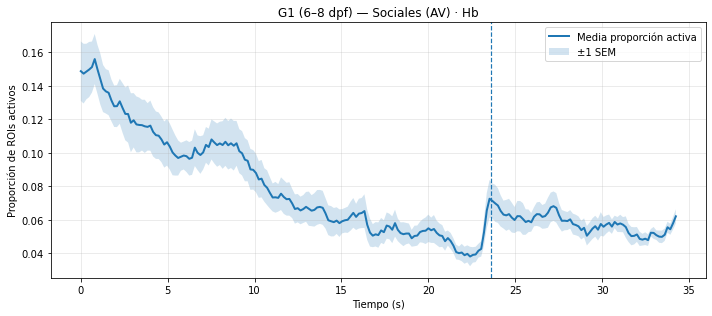

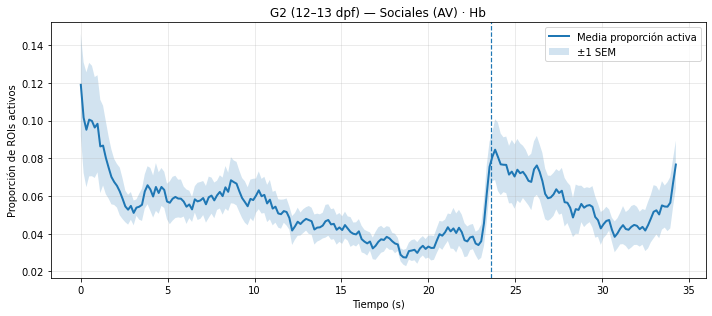

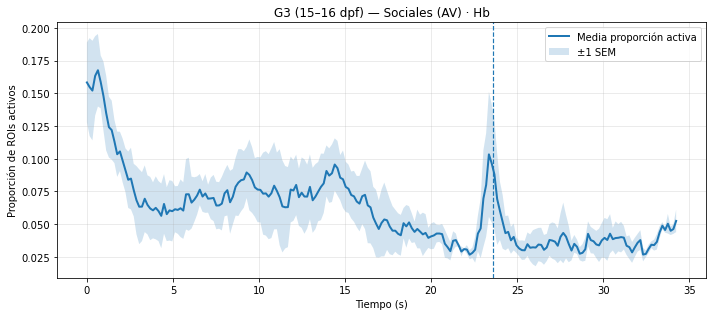

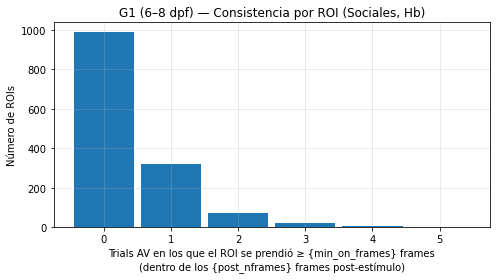

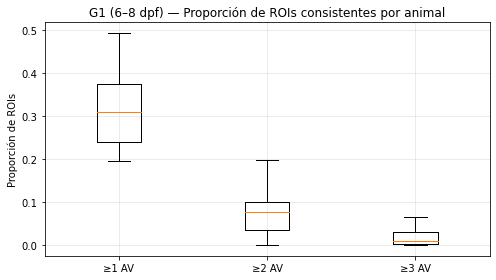

[G1 (6–8 dpf)] Proporción media de ROIs consistentes por umbral (animales sociales):
  ≥1 AV: mean=0.314, sd=0.102, n_animals=11
  ≥2 AV: mean=0.080, sd=0.059, n_animals=11
  ≥3 AV: mean=0.026, sd=0.037, n_animals=11


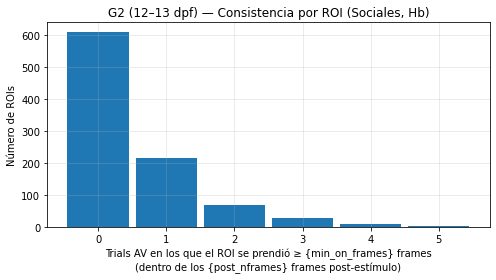

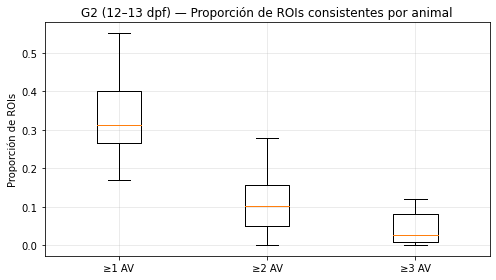

[G2 (12–13 dpf)] Proporción media de ROIs consistentes por umbral (animales sociales):
  ≥1 AV: mean=0.341, sd=0.125, n_animals=8
  ≥2 AV: mean=0.116, sd=0.098, n_animals=8
  ≥3 AV: mean=0.045, sd=0.048, n_animals=8


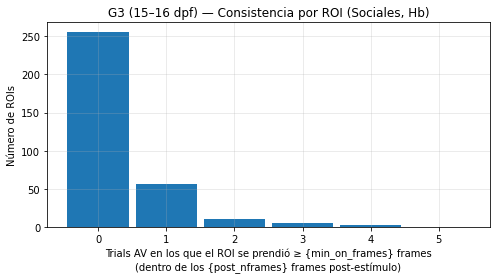

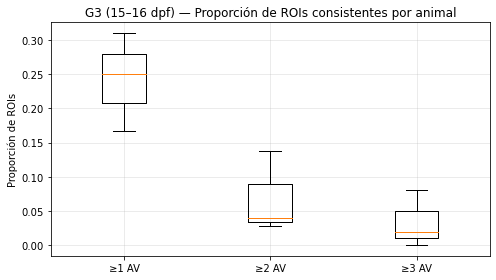

[G3 (15–16 dpf)] Proporción media de ROIs consistentes por umbral (animales sociales):
  ≥1 AV: mean=0.242, sd=0.072, n_animals=3
  ≥2 AV: mean=0.069, sd=0.060, n_animals=3
  ≥3 AV: mean=0.033, sd=0.042, n_animals=3


In [35]:
# import numpy as np
# import matplotlib.pyplot as plt
from collections import defaultdict

# ========= Parámetros que podés ajustar =========
region_key   = 'Hb'
stim_s       = 23.6          # tiempo de estímulo (s)
fps          = 6.25         # usado si no hay trial.frame_times
condicion    = 'AV'          # 'AV' (vis=1 & aud=1)
post_nframes = 6             # ventana post-estímulo (frames)
min_on_frames = 2            # umbral de "se prendió" dentro de la ventana
# ===============================================

# Definición de grupos (edad en dpf)
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}

def _es_social(area):
    return getattr(area, 'aislado', 1) == 0

def _cond(trial):
    return 'AV' if getattr(trial, 'vis', 0) == 1 and getattr(trial, 'aud', 0) == 1 else 'CTRL'

def _frame_times(trial, n_frames):
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft)
        # Aseguramos largo coherente:
        if ft.ndim == 1 and len(ft) == n_frames:
            return ft
    # fallback regular
    return np.arange(n_frames, dtype=float) / float(fps)

def _stim_index(frame_times, stim_s):
    # Índice del frame más cercano al tiempo de estímulo
    return int(np.argmin(np.abs(frame_times - stim_s)))

def _collect_animals_by_group(areas, grupos):
    grupos_animales = {g: [] for g in grupos}
    for area in areas.values():
        if not _es_social(area):
            continue
        for gname, pred in grupos.items():
            if pred(getattr(area, 'edad', -1)):
                grupos_animales[gname].append(area)
                break
    return grupos_animales

def _trial_prop_timecourse(trial, region_key):
    """Proporción de ROIs activos por frame en un trial (mean sobre ROIs)."""
    rb = trial.roi_binaries[region_key]  # (n_rois, n_frames)
    if rb.ndim != 2:
        raise ValueError("roi_binaries[region] debe ser 2D (rois x frames).")
    # Promedio sobre ROIs -> (n_frames,)
    return rb.mean(axis=0)

def _animal_mean_timecourse_AV(area, region_key):
    """Promedio (sobre trials AV) de la proporción de ROIs activos por frame para un animal."""
    tc_list = []
    min_len = None
    for tr in getattr(area, 'trials', []):
        if _cond(tr) != 'AV': 
            continue
        rb = tr.roi_binaries.get(region_key, None)
        if rb is None:
            continue
        tc = _trial_prop_timecourse(tr, region_key)
        min_len = len(tc) if min_len is None else min(min_len, len(tc))
        tc_list.append(tc)
    if not tc_list:
        return None
    # Alinear por longitud mínima
    tc_stack = np.stack([tc[:min_len] for tc in tc_list], axis=0)  # (n_trials_AV, min_len)
    return tc_stack.mean(axis=0)  # promedio sobre trials

def _group_mean_sem_timecourse(animals, region_key):
    """Apila el promedio por animal y luego calcula media y SEM del grupo."""
    animal_tc = []
    min_len = None
    for area in animals:
        tc = _animal_mean_timecourse_AV(area, region_key)
        if tc is None:
            continue
        min_len = len(tc) if min_len is None else min(min_len, len(tc))
        animal_tc.append(tc)
    if not animal_tc:
        return None, None, None
    X = np.stack([tc[:min_len] for tc in animal_tc], axis=0)  # (n_animals, T)
    mean = X.mean(axis=0)
    sem  = X.std(axis=0, ddof=1) / np.sqrt(X.shape[0]) if X.shape[0] > 1 else np.zeros_like(mean)
    return mean, sem, X

def _consistency_counts_per_roi(area, region_key, stim_s, post_nframes, min_on_frames):
    """Para un animal: cuenta, para cada ROI, en cuántos trials AV se activó >= min_on_frames dentro de los post_nframes tras el estímulo."""
    trials_av = [tr for tr in getattr(area, 'trials', []) if _cond(tr) == 'AV' and region_key in tr.roi_binaries]
    if not trials_av:
        return None  # sin AV
    # Determinar ventana post en cada trial (por si difiere el timing)
    roi_counts = None
    for tr in trials_av:
        rb = tr.roi_binaries[region_key]  # (n_rois, n_frames)
        n_rois, n_frames = rb.shape
        ft = _frame_times(tr, n_frames)
        i0 = _stim_index(ft, stim_s)
        i1 = min(i0 + 1 + post_nframes, n_frames)  # 6 frames siguientes (excluye el frame del estímulo)
        win = rb[:, i0+1:i1] if i0+1 < i1 else np.zeros((n_rois, 0), dtype=rb.dtype)

        # ROI "se prendió" en el trial si suma en ventana >= min_on_frames
        fired = (win.sum(axis=1) >= min_on_frames).astype(int)  # (n_rois,)
        if roi_counts is None:
            roi_counts = fired.astype(int)
        else:
            # Aseguramos mismo n_rois (si no, recortamos a la mínima)
            m = min(len(roi_counts), len(fired))
            roi_counts = roi_counts[:m] + fired[:m]
    return roi_counts  # enteros de 0..#AV_trials (idealmente 0..5)

def _summarize_consistency_group(animals, region_key, stim_s, post_nframes, min_on_frames):
    """Devuelve:
       - lista por animal del conteo por ROI (0..5)
       - vector por animal con proporción de ROIs 'consistentes' según distintos umbrales (>=1, >=2, >=3 AV)
    """
    per_animal_counts = []
    prop_by_thresh = defaultdict(list)  # keys: 1,2,3 (AV >= k)
    for area in animals:
        counts = _consistency_counts_per_roi(area, region_key, stim_s, post_nframes, min_on_frames)
        if counts is None:
            continue
        counts = np.asarray(counts)
        n_rois = counts.size
        per_animal_counts.append(counts)
        for k in (1, 2, 3):
            prop_by_thresh[k].append((counts >= k).sum() / n_rois)
    return per_animal_counts, prop_by_thresh

# ============ EJECUCIÓN ============

grupos_animales = _collect_animals_by_group(areas, grupos)

# 1) Proporción por frame y gráficos por grupo (media ± SEM)
for gname, animals in grupos_animales.items():
    mean, sem, X = _group_mean_sem_timecourse(animals, region_key)
    if mean is None:
        print(f"[{gname}] Sin datos AV válidos.")
        continue

    # Eje de tiempo (asumimos sampling uniforme a fps para el ploteo macro)
    T = len(mean)
    t = np.arange(T) / float(fps)

    # Marcar estímulo
    plt.figure(figsize=(10, 4.5))
    plt.plot(t, mean, linewidth=2, label='Media proporción activa')
    plt.fill_between(t, mean-sem, mean+sem, alpha=0.2, label='±1 SEM')
    plt.axvline(stim_s, linestyle='--', linewidth=1.2)
    plt.title(f"{gname} — Sociales (AV) · {region_key}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Proporción de ROIs activos")
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 2) Consistencia post-estímulo por grupo
for gname, animals in grupos_animales.items():
    counts_list, prop_by_thresh = _summarize_consistency_group(
        animals, region_key, stim_s, post_nframes, min_on_frames
    )
    if not counts_list:
        print(f"[{gname}] Sin datos para consistencia.")
        continue

    # a) Histograma agregado de “trial-counts” (0..5) sobre todos los ROIs de todos los animales
    all_counts = np.concatenate(counts_list)
    plt.figure(figsize=(7,4))
    bins = np.arange(-0.5, 5.5+1, 1)  # para barras centradas en 0..5
    plt.hist(all_counts, bins=bins, rwidth=0.9)
    plt.xticks(range(0, 6))
    plt.xlabel("Trials AV en los que el ROI se prendió ≥ {min_on_frames} frames\n(dentro de los {post_nframes} frames post-estímulo)")
    plt.ylabel("Número de ROIs")
    plt.title(f"{gname} — Consistencia por ROI (Sociales, {region_key})")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # b) Resumen por animal: proporción de ROIs con consistencia ≥ k trials AV
    #    (k = 1, 2, 3 como ejemplo)
    if prop_by_thresh:
        ks = sorted(prop_by_thresh.keys())
        data = [prop_by_thresh[k] for k in ks]
        plt.figure(figsize=(7,4))
        plt.boxplot(data, labels=[f"≥{k} AV" for k in ks], showfliers=False)
        plt.ylabel("Proporción de ROIs")
        plt.title(f"{gname} — Proporción de ROIs consistentes por animal")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        # También imprimimos medias por claridad
        print(f"[{gname}] Proporción media de ROIs consistentes por umbral (animales sociales):")
        for k in ks:
            arr = np.array(prop_by_thresh[k])
            print(f"  ≥{k} AV: mean={arr.mean():.3f}, sd={arr.std(ddof=1) if len(arr)>1 else 0:.3f}, n_animals={len(arr)}")


# Derecha/Izquierda


[G1 (6–8 dpf) · Izquierda] Ventana 23.6–24.6s  C=0.0485  AV=0.0724  Δ(AV−C)=0.0238
[G2 (12–13 dpf) · Izquierda] Ventana 23.6–24.6s  C=0.0453  AV=0.0770  Δ(AV−C)=0.0317
[G3 (15–16 dpf) · Izquierda] Ventana 23.6–24.6s  C=0.0310  AV=0.0446  Δ(AV−C)=0.0137
[G1 (6–8 dpf) · Derecha] Ventana 23.6–24.6s  C=0.0496  AV=0.0565  Δ(AV−C)=0.0070
[G2 (12–13 dpf) · Derecha] Ventana 23.6–24.6s  C=0.0459  AV=0.0797  Δ(AV−C)=0.0338
[G3 (15–16 dpf) · Derecha] Ventana 23.6–24.6s  C=0.0597  AV=0.0671  Δ(AV−C)=0.0073


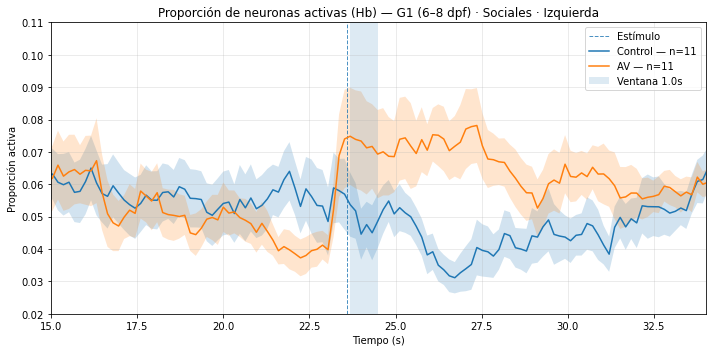

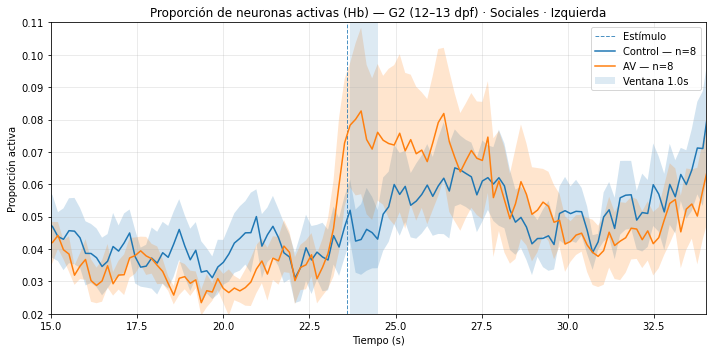

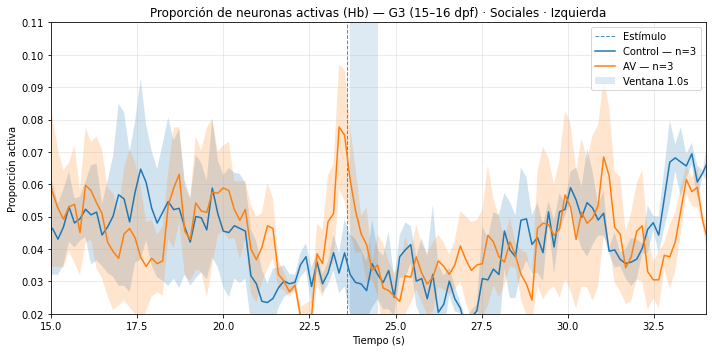

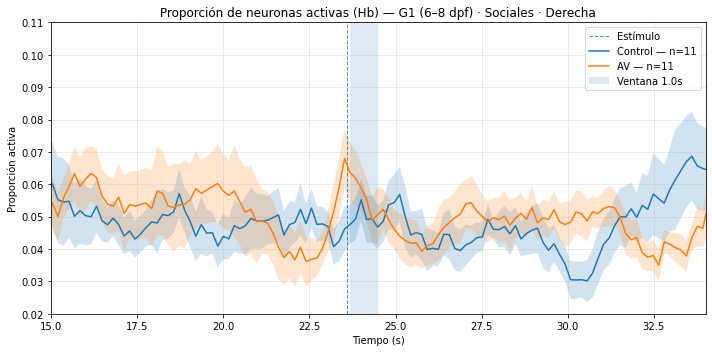

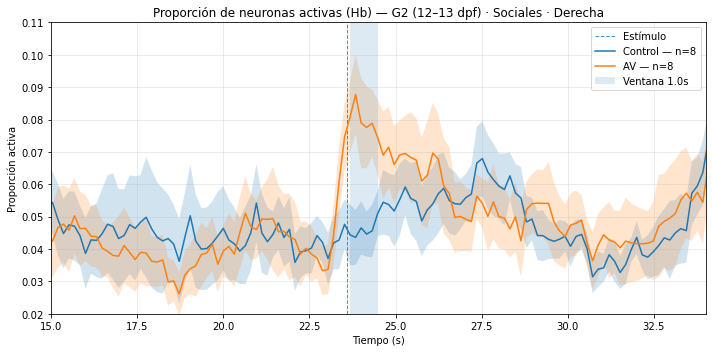

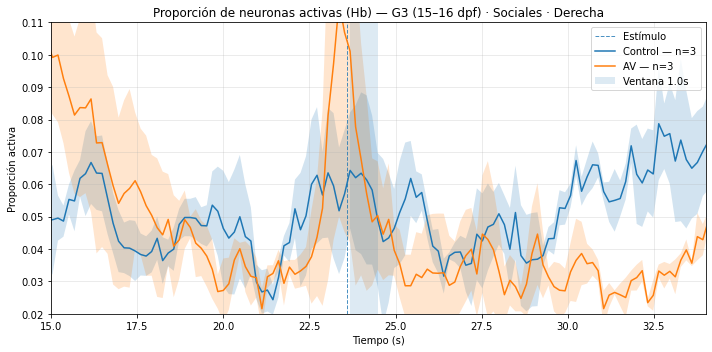

In [49]:
# === Parámetros que TENÉS que ajustar ==============================
region_key = 'Hb'
stim_s     = 23.6         # segundo del estímulo
win_s      = 1.0          # ventana post-estímulo (s)
fps        = 6.25         # <-- PONÉ TU FPS AQUÍ (float). Requerido si no hay trial.frame_times

# Grupos por edad (dpf)
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}

# === Utilidades ====================================================
# OJO: para “derecha” usá el complemento de roi_lefties:  ~areas[k].roi_lefties['Hb']
# Ejemplo directo: areas['113-1'].trials[0].roi_binaries['Hb'][~areas['113-1'].roi_lefties['Hb']]

def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0) == 1 and getattr(trial, 'aud', 0) == 1 else 'C'

def _trial_timebase(trial, fallback_fps):
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, dtype=float)
        if len(ft) > 1:
            dif = np.diff(ft)
            fps_est = 1.0 / np.median(dif)
        else:
            fps_est = fallback_fps
        return ft, fps_est

    t_fps = getattr(trial, 'fps', None)
    if t_fps is None:
        if fallback_fps is None:
            raise ValueError("Definí 'fps' o proveé trial.frame_times / trial.fps.")
        t_fps = fallback_fps

    rb = getattr(trial, 'roi_binaries', None)
    if rb is None or region_key not in rb:
        raise ValueError(f"Falta roi_binaries['{region_key}'].")
    arr = np.asarray(rb[region_key])            # (n_rois, n_frames)
    n_frames = arr.shape[1]
    t = np.arange(n_frames, dtype=float) / float(t_fps)
    return t, float(t_fps)

def _get_side_mask(area, region_key, side):
    """
    side in {'I','D'}.
    Devuelve máscara booleana por ROI para el lado pedido o None si no existe.
    """
    left_map = getattr(area, 'roi_lefties', None)
    if left_map is None or region_key not in left_map:
        return None
    left_mask = np.asarray(left_map[region_key], dtype=bool)
    return left_mask if side == 'I' else ~left_mask

def _prop_active_per_frame(trial, area, side):
    """
    Proporción de neuronas activas por frame (filtrando por lado).
    rows = ROIs del lado pedido; cols = tiempo.
    """
    rb = getattr(trial, 'roi_binaries', None)
    if rb is None or region_key not in rb:
        return None
    arr = np.asarray(rb[region_key])            # (n_rois, n_frames)
    side_mask = _get_side_mask(area, region_key, side)
    if side_mask is None:
        return None
    if side_mask.shape[0] != arr.shape[0]:
        return None
    if not np.any(side_mask):
        return None
    sub = arr[side_mask, :]
    arr_bin = (sub > 0).astype(float)
    return arr_bin.mean(axis=0)

def _truncate_to_common_length(list_of_arrays):
    L = [len(a) for a in list_of_arrays if a is not None]
    if not L:
        return [], 0
    m = min(L)
    return [a[:m] for a in list_of_arrays if a is not None], m

def _mean_sem_over_animals(animal_traces):
    if len(animal_traces) == 0:
        return None, None
    X, L = _truncate_to_common_length(animal_traces)
    if L == 0:
        return None, None
    M = np.vstack(X)
    mean = M.mean(axis=0)
    sem  = M.std(axis=0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros_like(mean)
    return mean, sem

def _window_indices(t, t0, dur):
    return (t >= t0) & (t < t0 + dur)

# === Procesamiento: solo animales sociales, por lado =================
social_keys = [k for k, a in areas.items() if getattr(a, 'aislado', 1) == 0]

# Estructura: resultados[side]['Gx']['C'/'AV'] -> {animals: [trace,...], t: array}
resultados = {
    'I': {g: {"C": {"animals": [], "t": None}, "AV": {"animals": [], "t": None}} for g in grupos.keys()},
    'D': {g: {"C": {"animals": [], "t": None}, "AV": {"animals": [], "t": None}} for g in grupos.keys()},
}

for k in social_keys:
    area = areas[k]
    edad = int(getattr(area, 'edad', -999))

    # Grupo por edad
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # Por lado
    for side in ['I', 'D']:
        per_trial = {"C": [], "AV": []}
        per_time  = {"C": [], "AV": []}

        for tr in getattr(area, 'trials', []):
            cond = _get_condition(tr)
            try:
                t, tr_fps = _trial_timebase(tr, fps)
                prop = _prop_active_per_frame(tr, area, side)
                if prop is None:
                    continue
                m = min(len(t), len(prop))
                per_trial[cond].append(prop[:m])
                per_time[cond].append(t[:m])
            except Exception:
                continue

        # Promedio por animal y condición
        for cond in ['C', 'AV']:
            if len(per_trial[cond]) == 0:
                continue
            series, m = _truncate_to_common_length(per_trial[cond])
            if m == 0:
                continue
            tseries, _ = _truncate_to_common_length(per_time[cond])
            t_common = tseries[0] if len(tseries) > 0 else np.arange(m) / (tr_fps if fps is None else fps)
            animal_mean = np.vstack(series).mean(axis=0)

            resultados[side][gname][cond]["animals"].append(animal_mean)
            if resultados[side][gname][cond]["t"] is None:
                resultados[side][gname][cond]["t"] = t_common

# === Gráficos (6 figuras: G1/G2/G3 × Izquierda/Derecha) =============
side_name = {'I': 'Izquierda', 'D': 'Derecha'}

for side in ['I', 'D']:
    for gname in grupos.keys():
        data = resultados[side][gname]
        mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
        mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

        # Base temporal
        tC = data['C']["t"]
        tA = data['AV']["t"]
        if mean_AV is not None and tA is not None:
            t_plot = tA[:len(mean_AV)]
        elif mean_C is not None and tC is not None:
            t_plot = tC[:len(mean_C)]
        else:
            print(f"[{gname} · {side_name[side]}] Sin datos.")
            continue

        w_idx = _window_indices(t_plot, stim_s, win_s)
        def _avg_win(x): return float(np.nanmean(x[w_idx])) if (x is not None and w_idx.any()) else np.nan
        avgC = _avg_win(mean_C) if mean_C is not None else np.nan
        avgA = _avg_win(mean_AV) if mean_AV is not None else np.nan
        delta = (avgA - avgC) if (not np.isnan(avgA) and not np.isnan(avgC)) else np.nan

        fig = plt.figure(figsize=(10, 5))
        plt.title(f"Proporción de neuronas activas ({region_key}) — {gname} · Sociales · {side_name[side]}")
        if w_idx.any():
            plt.axvspan(t_plot[w_idx][0], t_plot[w_idx][-1], alpha=0.15, label=f"Ventana {win_s:.1f}s")
        plt.axvline(stim_s, linestyle='--', linewidth=1, alpha=0.8, label="Estímulo")

        if mean_C is not None:
            nC = len(data['C']['animals'])
            plt.plot(t_plot, mean_C[:len(t_plot)], label=f"Control — n={nC}")
            if sem_C is not None:
                m = min(len(t_plot), len(sem_C))
                plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m], alpha=0.2)

        if mean_AV is not None:
            nA = len(data['AV']['animals'])
            plt.plot(t_plot, mean_AV[:len(t_plot)], label=f"AV — n={nA}")
            if sem_AV is not None:
                m = min(len(t_plot), len(sem_AV))
                plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m], alpha=0.2)

        plt.xlabel("Tiempo (s)")
        plt.ylabel("Proporción activa")
        plt.ylim(.02, .11)
        plt.xlim(15, 34)
        plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
        fig.patch.set_facecolor('white')
        # plt.savefig(f'{gname}_Sociales_{side_name[side]}.png', dpi=300, bbox_inches='tight')

        print(f"[{gname} · {side_name[side]}] Ventana {stim_s:.1f}–{stim_s+win_s:.1f}s  C={avgC:.4f}  AV={avgA:.4f}  Δ(AV−C)={delta:.4f}")


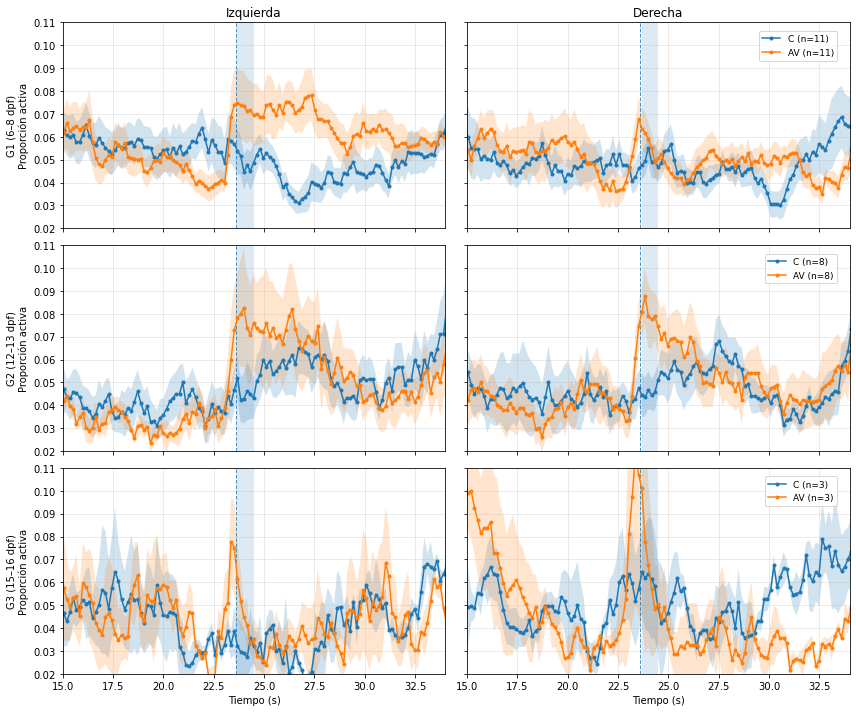

In [51]:
# === Re-graficar en grilla con leyenda interna por subplot =========
side_name = {'I': 'Izquierda', 'D': 'Derecha'}

fig, axes = plt.subplots(
    nrows=len(grupos), ncols=2, figsize=(12, 10),
    sharex=True, sharey=True
)

for r, gname in enumerate(grupos.keys()):
    for c, side in enumerate(['I', 'D']):
        ax = axes[r, c]
        data = resultados[side][gname]
        mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
        mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

        tC = data['C']["t"]
        tA = data['AV']["t"]
        if mean_AV is not None and tA is not None:
            t_plot = tA[:len(mean_AV)]
        elif mean_C is not None and tC is not None:
            t_plot = tC[:len(mean_C)]
        else:
            ax.set_visible(False)
            continue

        # Ventana y estímulo
        w_idx = _window_indices(t_plot, stim_s, win_s)
        if w_idx.any():
            ax.axvspan(t_plot[w_idx][0], t_plot[w_idx][-1], alpha=0.15)
        ax.axvline(stim_s, linestyle='--', linewidth=1, alpha=0.8)

        # Curvas
        if mean_C is not None:
            ax.plot(t_plot, mean_C[:len(t_plot)], label=f"C (n={len(data['C']['animals'])})", marker='o', markersize=3)
            if sem_C is not None:
                m = min(len(t_plot), len(sem_C))
                ax.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m], alpha=0.2)

        if mean_AV is not None:
            ax.plot(t_plot, mean_AV[:len(t_plot)], label=f"AV (n={len(data['AV']['animals'])})", marker='o', markersize=3)
            if sem_AV is not None:
                m = min(len(t_plot), len(sem_AV))
                ax.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m], alpha=0.2)

        # Ejes, títulos y leyenda interna
        ax.set_ylim(.02, .11)
        ax.set_xlim(15, 34)
        ax.grid(alpha=0.3)
        if r == 0:
            ax.set_title(side_name[side], fontsize=12)
        if c == 0:
            ax.set_ylabel(f"{gname}\nProporción activa")

        # >>> Leyenda adentro del panel
        if side =='D':
            ax.legend(
                loc="upper right",
                bbox_to_anchor=(0.98, 0.98),
                frameon=True, framealpha=0.8,
                fontsize=9, borderpad=0.4, handlelength=2
            )

# Etiqueta X solo en la última fila
for c in range(2):
    axes[-1, c].set_xlabel("Tiempo (s)")

fig.tight_layout()
fig.patch.set_facecolor('white')
plt.show()


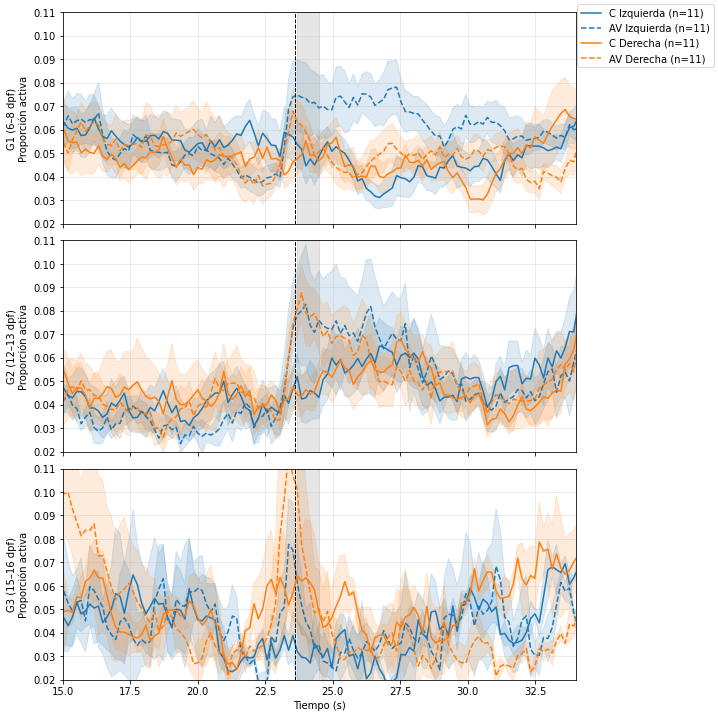

In [38]:
# === Re-graficar: 1 fila por grupo, cada gráfico combina izquierda y derecha ===
side_name = {'I': 'Izquierda', 'D': 'Derecha'}

fig, axes = plt.subplots(
    nrows=len(grupos), ncols=1, figsize=(10, 10),
    sharex=True, sharey=True
)

if len(grupos) == 1:
    axes = [axes]  # asegurar iterabilidad si hay un solo grupo

for r, gname in enumerate(grupos.keys()):
    ax = axes[r]

    colores_side = {'I': 'tab:blue', 'D': 'tab:orange'}

    for side in ['I', 'D']:
        data = resultados[side][gname]
        mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
        mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

        tC = data['C']["t"]
        tA = data['AV']["t"]
        if mean_AV is not None and tA is not None:
            t_plot = tA[:len(mean_AV)]
        elif mean_C is not None and tC is not None:
            t_plot = tC[:len(mean_C)]
        else:
            continue

        w_idx = _window_indices(t_plot, stim_s, win_s)
        if w_idx.any():
            ax.axvspan(t_plot[w_idx][0], t_plot[w_idx][-1], alpha=0.1, color="grey")
        ax.axvline(stim_s, linestyle='--', linewidth=1, alpha=0.8, color="k")

        if mean_C is not None:
            ax.plot(t_plot, mean_C[:len(t_plot)],
                    color=colores_side[side], linestyle='-',
                    label=f"C {side_name[side]} (n={len(data['C']['animals'])})")
            if sem_C is not None:
                m = min(len(t_plot), len(sem_C))
                ax.fill_between(t_plot[:m],
                                mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m],
                                color=colores_side[side], alpha=0.15)

        if mean_AV is not None:
            ax.plot(t_plot, mean_AV[:len(t_plot)],
                    color=colores_side[side], linestyle='--',
                    label=f"AV {side_name[side]} (n={len(data['AV']['animals'])})")
            if sem_AV is not None:
                m = min(len(t_plot), len(sem_AV))
                ax.fill_between(t_plot[:m],
                                mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m],
                                color=colores_side[side], alpha=0.15)

    ax.set_ylim(.02, .11)
    ax.set_xlim(15, 34)
    ax.grid(alpha=0.3)
    ax.set_ylabel(f"{gname}\nProporción activa")

axes[-1].set_xlabel("Tiempo (s)")

# Leyenda global
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.tight_layout(rect=[0, 0, 0.82, 1])
fig.patch.set_facecolor('white')
plt.show()


In [39]:
# === GLM Binomial por lado (Izq/Dcha) con SEs robustos por neurona (cluster) ===
# Requiere construir un df con columnas: ['y','n_frames','cond','fish_id','roi_id','side']
# donde y = #frames activos en la ventana; n_frames = #frames de la ventana.

# --- Parámetros ---
region_key  = 'Hb'
stim_s      = 23.6
win_s       = 1.0
fps         = 6.25
solo_social = True

grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}

import numpy as np, pandas as pd
import statsmodels.api as sm

# ---------- utilidades mínimas (reusa las tuyas si ya existen) ----------
def _get_condition(trial):
    return 'AV' if getattr(trial,'vis',0)==1 and getattr(trial,'aud',0)==1 else 'C'

def _trial_timebase(trial, fallback_fps):
    ft = getattr(trial,'frame_times',None)
    if ft is not None:
        ft = np.asarray(ft,float)
        fps_est = 1.0/np.median(np.diff(ft)) if len(ft)>1 else float(fallback_fps)
        return ft, float(fps_est)
    t_fps = getattr(trial,'fps',None) or float(fps)
    n_frames = np.asarray(trial.roi_binaries[region_key]).shape[1]
    t = np.arange(n_frames,dtype=float)/float(t_fps)
    return t, float(t_fps)

def _win_mask(t, t0, dur): return (t>=t0) & (t<t0+dur)

def _get_side_mask(area, region_key, side):
    left_map = getattr(area,'roi_lefties',None)
    if left_map is None or region_key not in left_map: return None
    left = np.asarray(left_map[region_key],bool)
    return left if side=='I' else ~left  # 'I' izquierda, 'D' derecha

# ---------- construir df por lado ----------
def construir_df_side(areas, pred_grupo=None, side='I', solo_social=True):
    rows = []
    for fish_id, area in areas.items():
        edad    = int(getattr(area,'edad',-999))
        aislado = int(getattr(area,'aislado',1))
        if solo_social and aislado!=0: 
            continue
        if pred_grupo is not None and not pred_grupo(edad):
            continue

        side_mask = _get_side_mask(area, region_key, side)
        if side_mask is None or not np.any(side_mask): 
            continue

        for tr in getattr(area,'trials',[]):
            cond = _get_condition(tr)
            try:
                t, _ = _trial_timebase(tr, fps)
            except Exception:
                continue
            w = _win_mask(t, stim_s, win_s)
            if not w.any(): 
                continue

            rb = getattr(tr,'roi_binaries',None)
            if rb is None or region_key not in rb: 
                continue
            B = np.asarray(rb[region_key])  # (n_rois, n_frames)
            if B.ndim!=2 or side_mask.shape[0]!=B.shape[0]:
                continue

            # filtra por lado y calcula #frames activos en la ventana
            B = (B>0).astype(np.uint8)[side_mask,:]
            y  = B[:, w].sum(axis=1)                   # éxitos
            nF = int(w.sum())                          # ensayos (frames ventana)
            roi_idxs = np.where(side_mask)[0]
            for i, roi_idx in enumerate(roi_idxs):
                rows.append({
                    "fish_id": str(fish_id),
                    "roi_id":  int(roi_idx),
                    "cond":    cond,                   # 'C' o 'AV'
                    "y":       int(y[i]),
                    "n_frames": nF,
                    "side":    side
                })
    return pd.DataFrame(rows)

# ---------- ajuste GLM binomial con cluster=neurona (si no lo tenés ya definido) ----------
def ajustar_glm_binomial_cluster(df):
    # Proporción y/n con var_weights = n
    y_prop = df['y'] / df['n_frames']
    X = sm.add_constant((df['cond']=='AV').astype(int), has_constant='add')
    glm = sm.GLM(y_prop, X, family=sm.families.Binomial(), var_weights=df['n_frames'])
    clusters = (df['fish_id'].astype(str)+'_'+df['roi_id'].astype(str)).values
    fit = glm.fit(cov_type='cluster', cov_kwds={'groups': clusters})

    beta = float(fit.params[1]); se=float(fit.bse[1]); z=float(fit.tvalues[1])
    p_two=float(fit.pvalues[1]); OR=float(np.exp(beta))
    lo, hi = beta-1.96*se, beta+1.96*se
    return {
        "beta_av": beta, "se_av": se, "z": z, "p_two": p_two,
        "OR": OR, "OR_lo": float(np.exp(lo)), "OR_hi": float(np.exp(hi)),
        "fit": fit
    }

# ---------- correr por grupo y por lado (I/D), y combinado ----------
res_glm = {'I':{}, 'D':{}}

for side in ['I','D']:
    print(f"\n===== Lado: {'Izquierda' if side=='I' else 'Derecha'} =====")
    for gname, gpred in grupos.items():
        df_g = construir_df_side(areas, pred_grupo=gpred, side=side, solo_social=solo_social)
        if df_g.empty or df_g['cond'].nunique()<2:
            print(f"[{gname}] Sin datos suficientes.")
            continue

        res = ajustar_glm_binomial_cluster(df_g)
        res_glm[side][gname] = res
        n_fish = df_g['fish_id'].nunique()
        n_neur = df_g.groupby(['fish_id','roi_id']).ngroups
        print(f"\n=== {gname} · Sociales={solo_social} ===")
        print(f"filas={len(df_g)}, peces={n_fish}, neuronas={n_neur}")
        print(f"Efecto AV (log-odds): {res['beta_av']:.4f} ± {res['se_av']:.4f} "
              f"[z={res['z']:.2f}, p={res['p_two']:.3g}]")
        print(f"OR={res['OR']:.3f}  IC95% OR=[{res['OR_lo']:.3f}, {res['OR_hi']:.3f}]")

    # combinado (todos los grupos) para este lado
    df_all = construir_df_side(areas, pred_grupo=None, side=side, solo_social=solo_social)
    if not df_all.empty and df_all['cond'].nunique()>=2:
        res_all = ajustar_glm_binomial_cluster(df_all)
        res_glm[side]["Todos"] = res_all
        n_fish = df_all['fish_id'].nunique()
        n_neur = df_all.groupby(['fish_id','roi_id']).ngroups
        print(f"\n=== Todos (combinado) · Sociales={solo_social} ===")
        print(f"filas={len(df_all)}, peces={n_fish}, neuronas={n_neur}")
        print(f"Efecto AV (log-odds): {res_all['beta_av']:.4f} ± {res_all['se_av']:.4f} "
              f"[z={res_all['z']:.2f}, p={res_all['p_two']:.3g}]")
        print(f"OR={res_all['OR']:.3f}  IC95% OR=[{res_all['OR_lo']:.3f}, {res_all['OR_hi']:.3f}]")
    else:
        print("\n[Todos] Sin datos suficientes.")



===== Lado: Izquierda =====

=== G1 (6–8 dpf) · Sociales=True ===
filas=7720, peces=11, neuronas=772
Efecto AV (log-odds): 0.3669 ± 0.0960 [z=3.82, p=0.000132]
OR=1.443  IC95% OR=[1.196, 1.742]

=== G2 (12–13 dpf) · Sociales=True ===
filas=4500, peces=8, neuronas=450
Efecto AV (log-odds): 0.7702 ± 0.1277 [z=6.03, p=1.63e-09]
OR=2.160  IC95% OR=[1.682, 2.775]

=== G3 (15–16 dpf) · Sociales=True ===
filas=1510, peces=3, neuronas=151
Efecto AV (log-odds): 0.4567 ± 0.2338 [z=1.95, p=0.0508]
OR=1.579  IC95% OR=[0.998, 2.497]

=== Todos (combinado) · Sociales=True ===
filas=13730, peces=22, neuronas=1373
Efecto AV (log-odds): 0.5176 ± 0.0731 [z=7.08, p=1.4e-12]
OR=1.678  IC95% OR=[1.454, 1.936]

===== Lado: Derecha =====

=== G1 (6–8 dpf) · Sociales=True ===
filas=6370, peces=11, neuronas=637
Efecto AV (log-odds): 0.1320 ± 0.0915 [z=1.44, p=0.149]
OR=1.141  IC95% OR=[0.954, 1.365]


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1537: SpecificationWarning: cov_type not fully supported with var_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1537: SpecificationWarning: cov_type not fully supported with var_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1537: SpecificationWarning: cov_type not fully supported with var_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1537: SpecificationWarning: cov_type not fully supported with var_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1537: SpecificationWarning: cov_type not fully supported with var_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\env


=== G2 (12–13 dpf) · Sociales=True ===
filas=4890, peces=8, neuronas=489
Efecto AV (log-odds): 0.5517 ± 0.1108 [z=4.98, p=6.39e-07]
OR=1.736  IC95% OR=[1.397, 2.157]

=== G3 (15–16 dpf) · Sociales=True ===
filas=1800, peces=3, neuronas=180
Efecto AV (log-odds): 0.0735 ± 0.2028 [z=0.36, p=0.717]
OR=1.076  IC95% OR=[0.723, 1.602]

=== Todos (combinado) · Sociales=True ===
filas=13060, peces=22, neuronas=1306
Efecto AV (log-odds): 0.2913 ± 0.0678 [z=4.30, p=1.72e-05]
OR=1.338  IC95% OR=[1.172, 1.528]


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1537: SpecificationWarning: cov_type not fully supported with var_weights
  SpecificationWarning)


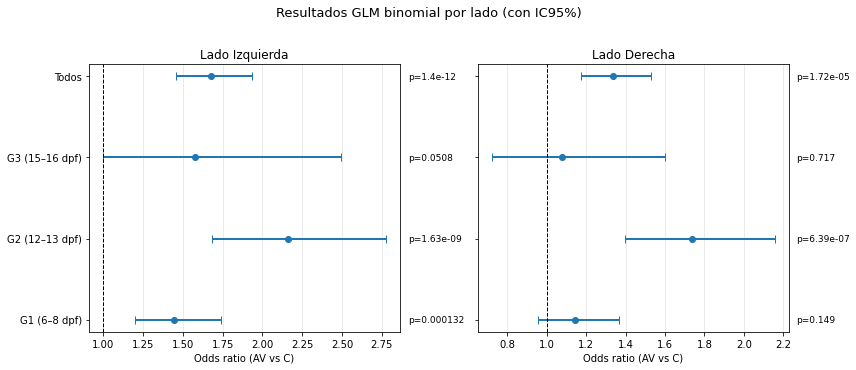

In [40]:
# === Visualización de resultados GLM por lado ===
# Usa el diccionario res_glm[side][grupo] creado en la celda anterior


order = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)", "Todos"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, side, title in zip(axes, ['I','D'], ['Izquierda','Derecha']):
    labels, ors, lo, hi = [], [], [], []
    pvals = []

    for g in order:
        if g in res_glm[side]:
            res = res_glm[side][g]
            labels.append(g)
            ors.append(res["OR"])
            lo.append(res["OR_lo"])
            hi.append(res["OR_hi"])
            pvals.append(res["p_two"])

    if not labels:
        ax.set_visible(False)
        continue

    ors, lo, hi = map(lambda x: np.array(x,float), [ors, lo, hi])
    y = np.arange(len(labels))
    xerr = np.vstack([ors - lo, hi - ors])

    ax.errorbar(ors, y, xerr=xerr, fmt='o', color='tab:blue',
                capsize=4, elinewidth=2)
    ax.axvline(1.0, linestyle='--', color='k', linewidth=1)

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Odds ratio (AV vs C)")
    ax.set_title(f"Lado {title}")
    ax.grid(alpha=0.3, axis='x')

    # anotar p-valores
    x_text = (np.nanmax(hi) if np.isfinite(np.nanmax(hi)) else 1.0) * 1.05
    for yi, p in enumerate(pvals):
        ax.text(x_text, yi, f"p={p:.3g}", va='center', fontsize=9)

fig.suptitle("Resultados GLM binomial por lado (con IC95%)", fontsize=13, y=1.02)
fig.tight_layout()
fig.patch.set_facecolor('white')
plt.show()



===== Lado: Izquierda =====
[G1 (6–8 dpf)] Wilcoxon (AV vs C) por neurona: n=772  p=0.0287  mediana(AV−C)=0.0000
[G1 (6–8 dpf)] GLM Binomial (cluster=neurona)  filas=7720  peces=11  neuronas=772  → OR=1.253  IC95% [1.070, 1.468]  p=0.00516
[G2 (12–13 dpf)] Wilcoxon (AV vs C) por neurona: n=450  p=1.43e-08  mediana(AV−C)=0.0000
[G2 (12–13 dpf)] GLM Binomial (cluster=neurona)  filas=4500  peces=8  neuronas=450  → OR=1.917  IC95% [1.566, 2.347]  p=2.85e-10
[G3 (15–16 dpf)] Wilcoxon (AV vs C) por neurona: n=151  p=0.0929  mediana(AV−C)=0.0000
[G3 (15–16 dpf)] GLM Binomial (cluster=neurona)  filas=1510  peces=3  neuronas=151  → OR=1.496  IC95% [0.993, 2.253]  p=0.0541
[Todos] Wilcoxon (AV vs C) por neurona: n=1373  p=8.37e-09  mediana(AV−C)=0.0000
[Todos] GLM Binomial (cluster=neurona)  filas=13730  peces=22  neuronas=1373  → OR=1.502  IC95% [1.333, 1.692]  p=2.39e-11

===== Lado: Derecha =====
[G1 (6–8 dpf)] Wilcoxon (AV vs C) por neurona: n=637  p=0.229  mediana(AV−C)=0.0000
[G1 (6–8 dpf

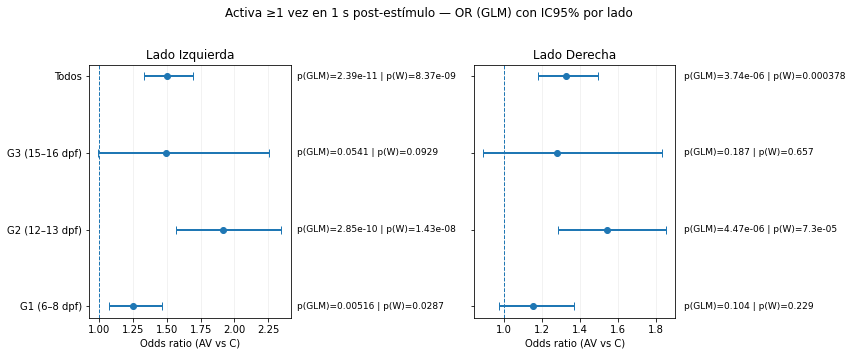

In [41]:
# === Hipótesis 2 (lado-específica): “Hay más neuronas que se prenden ≥1 vez en 1 s post-estímulo (AV > C)” ===
# Evalúa por lado Izquierda/Derecha con:
#   (A) Wilcoxon pareado por neurona
#   (B) GLM Binomial con SEs robustos (cluster=neurona)

# --- Parámetros (ajustar) ---
region_key  = 'Hb'
stim_s      = 23.6
win_s       = 1.0
fps         = 6.25
solo_social = True

grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
    "Todos":          lambda e: True,
}

# --- Utilidades comunes ---
import numpy as np, pandas as pd
from scipy.stats import wilcoxon
import statsmodels.api as sm
import matplotlib.pyplot as plt

def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0)==1 and getattr(trial, 'aud', 0)==1 else 'C'

def _trial_timebase(trial, fallback_fps):
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, dtype=float)
        fps_est = 1.0/np.median(np.diff(ft)) if len(ft)>1 else float(fallback_fps)
        return ft, float(fps_est)
    t_fps = getattr(trial, 'fps', None) or float(fallback_fps)
    n_frames = np.asarray(trial.roi_binaries[region_key]).shape[1]
    t = np.arange(n_frames, dtype=float)/float(t_fps)
    return t, float(t_fps)

def _win_mask(t, t0, dur):
    return (t >= t0) & (t < t0 + dur)

def _get_side_mask(area, region_key, side):
    left_map = getattr(area, 'roi_lefties', None)
    if left_map is None or region_key not in left_map:
        return None
    left_mask = np.asarray(left_map[region_key], dtype=bool)
    return left_mask if side=='I' else ~left_mask  # I=izquierda, D=derecha

# --- Construcción de dataset Bernoulli por lado ---
def construir_df_any_side(areas, pred_grupo, side, solo_social=True):
    rows = []
    for fish_id, area in areas.items():
        edad    = int(getattr(area, 'edad', -999))
        aislado = int(getattr(area, 'aislado', 1))
        if solo_social and aislado!=0: 
            continue
        if not pred_grupo(edad):
            continue

        side_mask = _get_side_mask(area, region_key, side)
        if side_mask is None:
            continue

        for tr in getattr(area, 'trials', []):
            cond = _get_condition(tr)
            try:
                t, _ = _trial_timebase(tr, fps)
            except Exception:
                continue
            w = _win_mask(t, stim_s, win_s)
            if not w.any(): 
                continue
            rb = getattr(tr, 'roi_binaries', None)
            if rb is None or region_key not in rb:
                continue
            B = np.asarray(rb[region_key])  # (n_rois, n_frames)
            if B.ndim!=2 or side_mask.shape[0] != B.shape[0] or not np.any(side_mask):
                continue

            B = (B>0).astype(np.uint8)[side_mask, :]  # filtra por lado
            y_any = (B[:, w].sum(axis=1) > 0).astype(np.uint8)

            # mapear índices locales (lado) a globales solo para clave única por neurona
            roi_idxs = np.where(side_mask)[0]
            for local_i, roi_idx in enumerate(roi_idxs):
                rows.append({
                    "fish_id": str(fish_id),
                    "roi_id":  int(roi_idx),   # id global del ROI
                    "cond":    cond,           # 'C' o 'AV'
                    "y_any":   int(y_any[local_i]),
                    "edad":    edad,
                    "aislado": aislado,
                    "side":    side            # 'I' o 'D'
                })
    return pd.DataFrame(rows)

def wilcoxon_pareado_por_neurona(df_any):
    def _agg(grp):
        out = grp.groupby('cond')['y_any'].mean()
        return pd.Series({"C": out.get('C', np.nan), "AV": out.get('AV', np.nan)})
    paired = (df_any.groupby(['fish_id','roi_id'], as_index=False)
                   .apply(_agg)
                   .dropna())
    if len(paired)==0:
        return None, None, None
    stat, p = wilcoxon(paired['AV'], paired['C'], alternative='two-sided')
    delta_med = float((paired['AV'] - paired['C']).median())
    return stat, p, delta_med

def glm_binomial_cluster(df_any):
    X = sm.add_constant((df_any['cond']=='AV').astype(int), has_constant='add')
    y = df_any['y_any'].astype(float).values
    clusters = (df_any['fish_id'].astype(str) + "_" + df_any['roi_id'].astype(str)).values
    glm = sm.GLM(y, X, family=sm.families.Binomial())
    fit = glm.fit(cov_type='cluster', cov_kwds={'groups': clusters})

    beta = float(fit.params[1])
    se   = float(fit.bse[1])
    z    = float(fit.tvalues[1])
    p    = float(fit.pvalues[1])
    OR   = float(np.exp(beta))
    lo, hi = beta - 1.96*se, beta + 1.96*se
    return {"beta_av": beta, "se_av": se, "z": z, "p": p,
            "OR": OR, "OR_lo": float(np.exp(lo)), "OR_hi": float(np.exp(hi)),
            "fit": fit}

# --- Correr por lado y por grupo ---
res_any = {'I':{}, 'D':{}}
wilcoxon_pvals = {'I':{}, 'D':{}}

for side in ['I','D']:
    print(f"\n===== Lado: {'Izquierda' if side=='I' else 'Derecha'} =====")
    for gname, pred in grupos.items():
        df_g = construir_df_any_side(areas, pred, side, solo_social=solo_social)
        if df_g.empty or df_g['cond'].nunique()<2:
            print(f"[{gname}] Sin datos suficientes.")
            continue

        stat, p_wil, d_med = wilcoxon_pareado_por_neurona(df_g)
        wilcoxon_pvals[side][gname] = p_wil
        if p_wil is not None:
            n_pairs = df_g.groupby(['fish_id','roi_id']).ngroups
            print(f"[{gname}] Wilcoxon (AV vs C) por neurona: n={n_pairs}  p={p_wil:.3g}  mediana(AV−C)={d_med:.4f}")

        res = glm_binomial_cluster(df_g)
        res_any[side][gname] = res
        n_fish = df_g['fish_id'].nunique()
        n_neur = df_g.groupby(['fish_id','roi_id']).ngroups
        print(f"[{gname}] GLM Binomial (cluster=neurona)  filas={len(df_g)}  peces={n_fish}  neuronas={n_neur}  "
              f"→ OR={res['OR']:.3f}  IC95% [{res['OR_lo']:.3f}, {res['OR_hi']:.3f}]  p={res['p']:.3g}")

# --- Forest plots lado-específicos (dos columnas: I y D) ---
order = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)", "Todos"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for ax, side, title in zip(axes, ['I','D'], ['Izquierda','Derecha']):
    labels, ors, lo, hi = [], [], [], []
    p_glm_list, p_wil_list = [], []
    for g in order:
        if g in res_any[side]:
            labels.append(g)
            ors.append(res_any[side][g]["OR"])
            lo.append(res_any[side][g]["OR_lo"])
            hi.append(res_any[side][g]["OR_hi"])
            p_glm_list.append(res_any[side][g]["p"])
            p_wil_list.append(wilcoxon_pvals[side].get(g, np.nan))

    if not labels:
        ax.set_visible(False); continue

    ors = np.array(ors, float); lo = np.array(lo, float); hi = np.array(hi, float)
    y = np.arange(len(labels))
    xerr = np.vstack([ors - lo, hi - ors])

    ax.errorbar(ors, y, xerr=xerr, fmt='o', capsize=4, elinewidth=2)
    ax.axvline(1.0, linestyle='--', linewidth=1)
    ax.set_yticks(y); ax.set_yticklabels(labels)
    ax.set_xlabel("Odds ratio (AV vs C)")
    ax.set_title(f"Lado {title}")
    ax.grid(alpha=0.2, axis='x')

    x_text = (np.nanmax(hi) if np.isfinite(np.nanmax(hi)) else 1.0) * 1.05
    for yi, (pg, pw) in enumerate(zip(p_glm_list, p_wil_list)):
        ax.text(x_text, yi, f"p(GLM)={pg:.3g} | p(W)={pw:.3g}", va='center', fontsize=9)

fig.suptitle("Activa ≥1 vez en 1 s post-estímulo — OR (GLM) con IC95% por lado", y=1.02, fontsize=12)
fig.tight_layout()
fig.patch.set_facecolor('white')
plt.show()


# Permite sacar neuronas poco activas (no hace diferencia)

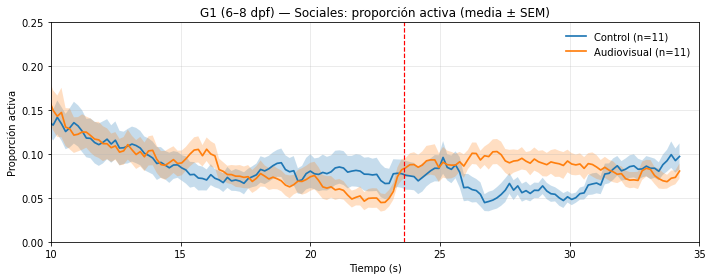

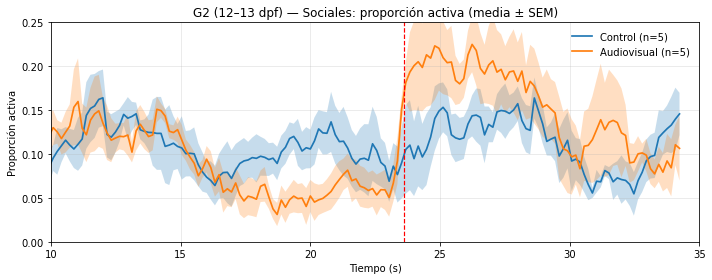

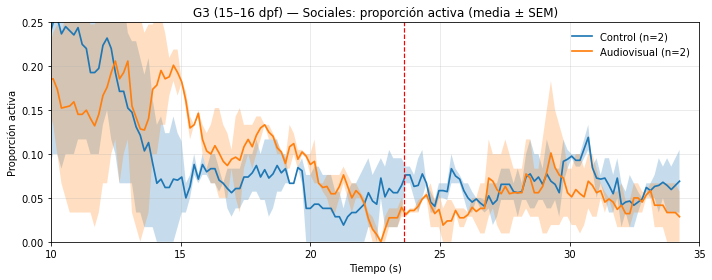

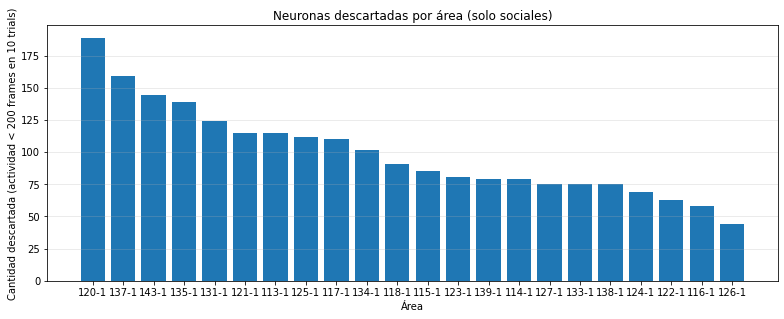

=== Resumen filtrado de neuronas (solo sociales) ===
- 120-1: descartadas=189, mantenidas=63, total=252
- 137-1: descartadas=159, mantenidas=0, total=159
- 143-1: descartadas=144, mantenidas=0, total=144
- 135-1: descartadas=139, mantenidas=7, total=146
- 131-1: descartadas=124, mantenidas=0, total=124
- 121-1: descartadas=115, mantenidas=34, total=149
- 113-1: descartadas=115, mantenidas=53, total=168
- 125-1: descartadas=112, mantenidas=6, total=118
- 117-1: descartadas=110, mantenidas=7, total=117
- 134-1: descartadas=102, mantenidas=63, total=165
- 118-1: descartadas=91, mantenidas=41, total=132
- 115-1: descartadas=85, mantenidas=21, total=106
- 123-1: descartadas=81, mantenidas=41, total=122
- 139-1: descartadas=79, mantenidas=21, total=100
- 114-1: descartadas=79, mantenidas=20, total=99
- 127-1: descartadas=75, mantenidas=23, total=98
- 133-1: descartadas=75, mantenidas=0, total=75
- 138-1: descartadas=75, mantenidas=12, total=87
- 124-1: descartadas=69, mantenidas=27, total=96

In [47]:
# ====== Parámetros editables ======
ROI_KEY = 'Hb'
FPS = 6.25
Y_MAX = .25  
X_MIN = 10             # Límite superior del eje Y para proporciones
T_END_S = 0.0              # Recorte del tiempo a graficar en segundos (0.0 = sin recortar)
STIM_LINE_S = 23.6         # Línea vertical punteada roja (en segundos). Poné None para no dibujarla.
MIN_ACTIVE_FRAMES = 200    # Umbral de actividad mínima por neurona (suma en los 10 trials)

# Grupos etarios
GRUPOS = {
    "G1 (6–8 dpf)":  {6, 7, 8},
    "G2 (12–13 dpf)": {12, 13},
    "G3 (15–16 dpf)": {15, 16},
}

# Contenedores para curvas por grupo (solo sociales)
grupos_data = {g: {"ctrl": [], "av": []} for g in GRUPOS}

# Para el gráfico final: neuronas descartadas por área (solo sociales)
removed_by_area = {}   # {area_key: cantidad_descartada}
kept_by_area = {}      # {area_key: cantidad_mantenida}

# Iteramos por áreas (solo sociales)
if hasattr(areas, "items"):  # dict típico
    iterator = areas.items()
else:                        # lista u otro iterable
    iterator = [(str(i), a) for i, a in enumerate(areas)]

for area_key, area in iterator:
    if getattr(area, "aislado", None) != 0:
        continue  # solo sociales

    edad = int(area.edad)
    # Determinar grupo etario
    grupo_nombre = None
    for gname, edades in GRUPOS.items():
        if edad in edades:
            grupo_nombre = gname
            break
    if grupo_nombre is None:
        continue  # fuera de los grupos pedidos

    # === Filtrado de neuronas poco activas (se evalúa con TODOS los trials del área) ===
    # Supuesto: todos los trials tienen mismo nro de frames y misma cantidad de neuronas.
    trials_area = getattr(area, "trials", [])
    # Encontrar primer trial válido para conocer dimensiones:
    n_neuronas = None
    for tr in trials_area:
        rb = getattr(tr, "roi_binaries", None)
        if isinstance(rb, dict) and ROI_KEY in rb:
            mat0 = np.asarray(rb[ROI_KEY], dtype=float)
            n_neuronas = mat0.shape[0]
            break
    if n_neuronas is None:
        # sin datos válidos para esta área
        continue

    # Acumulador de frames activos por neurona a lo largo de TODOS los trials (ctrl + AV)
    active_counts = np.zeros(n_neuronas, dtype=int)
    for tr in trials_area:
        rb = getattr(tr, "roi_binaries", None)
        if isinstance(rb, dict) and ROI_KEY in rb:
            mat = np.asarray(rb[ROI_KEY], dtype=float)  # [N_neuronas x N_frames], 0/1
            # Sumo, para cada neurona, cuántos frames estuvo activa en este trial
            active_counts += mat.sum(axis=1).astype(int)

    # Máscara de neuronas a conservar (al menos MIN_ACTIVE_FRAMES en el total de 10 trials)
    mask_keep = active_counts >= MIN_ACTIVE_FRAMES
    kept = int(mask_keep.sum())
    removed = int((~mask_keep).sum())
    kept_by_area[area_key] = kept
    removed_by_area[area_key] = removed

    # Si no queda ninguna neurona, no aportamos esta área
    if kept == 0:
        continue

    # === Construcción de series por condición (promedio por área, luego al grupo) ===
    # Control (vis=0, aud=0)
    ctrl_series = []
    # AV (vis=1, aud=1)
    av_series = []

    for tr in trials_area:
        vis = getattr(tr, "vis", None)
        aud = getattr(tr, "aud", None)
        rb = getattr(tr, "roi_binaries", None)
        if not (isinstance(rb, dict) and ROI_KEY in rb):
            continue

        mat = np.asarray(rb[ROI_KEY], dtype=float)  # [N_neuronas x N_frames]
        mat = mat[mask_keep, :]                     # aplicamos el filtro de neuronas

        # Proporción activa por frame = promedio sobre neuronas
        prop = mat.mean(axis=0)  # [N_frames], valores en [0,1]

        if vis == 0 and aud == 0:
            ctrl_series.append(prop)
        elif vis == 1 and aud == 1:
            av_series.append(prop)

    # Promedio por área (si hay datos)
    if ctrl_series:
        area_ctrl = np.vstack(ctrl_series).mean(axis=0)  # [N_frames]
        grupos_data[grupo_nombre]["ctrl"].append(area_ctrl)

    if av_series:
        area_av = np.vstack(av_series).mean(axis=0)      # [N_frames]
        grupos_data[grupo_nombre]["av"].append(area_av)

# ========== Graficado por grupos (media ± SEM), con recorte temporal y línea roja ==========
for gname, data in grupos_data.items():
    ctrl_list = data["ctrl"]
    av_list   = data["av"]

    if not ctrl_list and not av_list:
        plt.figure(figsize=(10, 4))
        plt.title(f"{gname} — sin datos sociales válidos")
        plt.xlabel("Tiempo (s)")
        plt.ylabel("Proporción de neuronas activas")
        plt.ylim(0, Y_MAX)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        continue

    ctrl_M = np.vstack(ctrl_list) if ctrl_list else None  # [N_anim x N_frames]
    av_M   = np.vstack(av_list)   if av_list   else None  # [N_anim x N_frames]

    n_frames = ctrl_M.shape[1] if ctrl_M is not None else av_M.shape[1]

    # Recorte temporal (si T_END_S > 0)
    if T_END_S and T_END_S > 0:
        idx_end = int(round(T_END_S * FPS))
        idx_end = max(1, min(idx_end, n_frames))
    else:
        idx_end = n_frames

    t = (np.arange(n_frames) / FPS)[:idx_end]

    plt.figure(figsize=(10, 4))

    # Control
    if ctrl_M is not None:
        ctrl_M_crop = ctrl_M[:, :idx_end]
        ctrl_mean = ctrl_M_crop.mean(axis=0)
        n_ctrl = ctrl_M_crop.shape[0]
        ctrl_sem = (ctrl_M_crop.std(axis=0, ddof=1) / np.sqrt(n_ctrl)) if n_ctrl > 1 else np.zeros_like(ctrl_mean)
        plt.plot(t, ctrl_mean, label=f"Control (n={n_ctrl})", linewidth=1.7)
        plt.fill_between(t, ctrl_mean - ctrl_sem, ctrl_mean + ctrl_sem, alpha=0.25)

    # Audiovisual
    if av_M is not None:
        av_M_crop = av_M[:, :idx_end]
        av_mean = av_M_crop.mean(axis=0)
        n_av = av_M_crop.shape[0]
        av_sem = (av_M_crop.std(axis=0, ddof=1) / np.sqrt(n_av)) if n_av > 1 else np.zeros_like(av_mean)
        plt.plot(t, av_mean, label=f"Audiovisual (n={n_av})", linewidth=1.7)
        plt.fill_between(t, av_mean - av_sem, av_mean + av_sem, alpha=0.25)

    # Línea roja punteada (si cae dentro del rango graficado)
    if STIM_LINE_S is not None and STIM_LINE_S <= t[-1]:
        plt.axvline(x=STIM_LINE_S, linestyle='--', linewidth=1.2, color='red')

    plt.title(f"{gname} — Sociales: proporción activa (media ± SEM)")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Proporción activa")
    plt.ylim(0, Y_MAX)
    plt.xlim(X_MIN, 35)
    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# ========== Gráfico final: neuronas descartadas por área ==========
if removed_by_area:
    # Ordenamos por cantidad descartada (descendente)
    area_keys = list(removed_by_area.keys())
    order = np.argsort([-removed_by_area[k] for k in area_keys])
    area_sorted = [area_keys[i] for i in order]
    removed_sorted = [removed_by_area[k] for k in area_sorted]
    kept_sorted = [kept_by_area.get(k, 0) for k in area_sorted]
    total_sorted = [removed_sorted[i] + kept_sorted[i] for i in range(len(area_sorted))]

    plt.figure(figsize=(max(8, 0.5*len(area_sorted)), 4.5))
    plt.bar(area_sorted, removed_sorted)
    plt.title("Neuronas descartadas por área (solo sociales)")
    plt.xlabel("Área")
    plt.ylabel("Cantidad descartada (actividad < {thr} frames en 10 trials)".format(thr=MIN_ACTIVE_FRAMES))
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # (Opcional) imprimir un pequeño resumen en texto
    print("=== Resumen filtrado de neuronas (solo sociales) ===")
    for k in area_sorted:
        print(f"- {k}: descartadas={removed_by_area[k]}, mantenidas={kept_by_area.get(k, 0)}, total={removed_by_area[k] + kept_by_area.get(k, 0)}")
else:
    print("No se encontraron áreas sociales con datos válidos para calcular neuronas descartadas.")
